# HW02-2：房地产上市公司财务特征分析

| 项目 | 内容 |
|---|---|
| 姓名 | 魏致衡 |
| 学号 | LN429 |
| 课程 / 教师 | LN429 金融计量 / 连玉君 |
| 作业页面 | <https://lianxhcn.github.io/FinEco/exercises/hw-02.html> |
| GitHub 仓库 | <https://github.com/lh3536/FinEco-hw> |
| HW02-1 目录 | <https://github.com/lh3536/FinEco-hw/tree/main/hw02-1> |
| HW02-2 目录 | <https://github.com/lh3536/FinEco-hw/tree/main/hw02-2> |
| 数据来源 | CSMAR（中山大学授权）：上市公司基本信息年度表 `STK_LISTEDCOINFOANL`、中国上市公司股权性质文件 `EN_EquityNatureAll`、上市公司上市状态变更表 `STK_ITEMCHANGE`、资产负债表 `FS_Combas`（主表 221438189，另有一份 220455131 仅作交叉核对）、利润表 `FS_Comins` |
| 下载日期 | 2026-09-28 |
| 样本期 | 2005—2015 年，年度（12-31）**合并报表**，金额单位为元；2004 年资产负债表**只**用作 2005 年 ROA/ROE 平均余额中的期初值 |

**AI 使用声明**

- **使用的工具：** ChatGPT / Codex（OpenAI）与 Claude（Anthropic，Cowork 模式）。
- **参与环节：**
  - 原始 ZIP 的识别与字段审计；
  - 上市状态变更表 CSV 解析问题的诊断；
  - 合并与比率计算代码；
  - 图表；
  - Notebook 结构与文字初稿。

  两个工具**各自独立完成了一个版本**，随后由 Claude 对照官方评分标准做交叉审计并合并。
- **关键提示词（摘录）：**
  - “Use the historical industry classification in each year … Do NOT take today's real-estate companies and backfill them into earlier years.”
  - “Never convert missing short-term borrowing or long-term borrowing to zero merely for convenience.”
- **核验与修正：**
  - 两个独立版本得到了相同的样本规模（1,193 个公司-年、172 家公司），合并也都是 1:1 完全匹配；
  - 代码中用 `assert` 核对行数、键唯一性与合并关系，并用独立脚本重算了关键统计量；
  - 交叉审计后修正了三处：
    1. 把“产权不明”（当年股权性质缺失）从“其他”中单列出来，符合官方的四类计数要求；
    2. 如实披露 CSMAR 的“短期借款/长期借款”包括向**其他金融机构**的借款，并不是纯粹的银行借款；
    3. 样本处理表补充了每个阶段的公司数与公司-年数。

  所有数字都来自下方代码的实际输出。

## 分析目标与思路

本作业描述 2005—2015 年 A 股房地产上市公司的数量、产权结构，以及六项财务指标的演变，并比较国企与民营公司之间的**描述性差异**。核心原则是使用**逐年的历史口径**：第 t 年的样本由 t 年末是否已上市、t 年的行业代码和 t 年的实际控制人性质共同决定。这样得到的是一个非平衡面板，公司可以上市、退市、转入或转出行业、变更产权，从而避免用今天的名单回填历史所造成的幸存者偏差。

- 行业：CSMAR 年度表逐年的证监会 2012 版代码，K70 = 房地产业，各年使用同一分类标准；
- 产权：按当年实际控制人性质分为国企、民营、其他、产权不明，**非国有不直接等于民营**；
- 指标：按官方公式计算公司层面的比率，均值是公司比率的算术平均，同时报告中位数和有效样本量；
- 离群值：逐个指标检查。主结果保留原始值，只在平均权益 ≤ 0 时把 ROE 设为缺失；另用 1%/99% 缩尾做敏感性分析；
- 国企与民营的差异只作描述，不作因果解释。

## 0. 官方要求清单

| 官方要求 | 位置 |
|---|---|
| CSMAR 2005—2015 年房地产 A 股、合并报表；按年末上市状态、行业、产权构建非平衡面板 | §2—§4 |
| 产权按当年实际控制人性质分类，非国有 ≠ 民营 | §4 |
| 样本处理表：下载、筛选、合并、变量构造各阶段的公司数与公司-年数 | §4.3 |
| 六项指标：资产负债率、bankloan、短期负债占比、ROA（平均总资产）、ROE（平均权益）、Cash_TA | §6 |
| 零分母、负权益、极端比率的处理规则及其影响 | §6—§7 |
| 每年公司总数，以及国企、民营、其他、产权不明的数量与占比；公司数去重，不因指标缺失而减少 | §5 |
| 每个指标：全部公司均值与中位数时序图；国企 vs 民营的均值图与中位数图；年度有效样本量表 | §6.3、§8 |
| 解释数量、结构、指标的变化，均值与中位数的差异，国企与民营的差异，异常来自离群值还是样本构成 | 各节、§9—§10 |

## 1. 环境与原始数据审计

本节确认每个原始文件的内容与用途，并记录文件指纹以保证可复现。原始 ZIP 只读，CSV 直接从 ZIP 内读取，路径以 Notebook 所在目录为基准。

- 记录 6 个 ZIP 的成员文件与 SHA-256；
- 读取 CSMAR 字段字典，确认各科目的含义；
- 明确每个表的主键与用途，并识别重复导出的文件。

In [1]:
import io, re, zipfile, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

BASE = Path.cwd()
if not (BASE / "data" / "raw").exists() and (BASE / "hw02-2" / "data" / "raw").exists():
    BASE = BASE / "hw02-2"
RAW = BASE / "data" / "raw"
INTERIM, PROC = BASE / "data" / "interim", BASE / "data" / "processed"
FIG, TAB, QA = BASE / "outputs" / "figures", BASE / "outputs" / "tables", BASE / "outputs" / "qa"
for p in (INTERIM, PROC, FIG, TAB, QA):
    p.mkdir(parents=True, exist_ok=True)
assert RAW.exists(), "找不到 data/raw：请按 data/README.md 放置 CSMAR 原始 ZIP"

cands = ["Noto Sans CJK SC", "Noto Sans CJK JP", "Source Han Sans SC", "SimHei", "Microsoft YaHei",
         "PingFang SC", "Heiti SC", "WenQuanYi Micro Hei", "Arial Unicode MS"]
avail = {f.name for f in font_manager.fontManager.ttflist}
CJK = next((c for c in cands if c in avail), None)
if CJK:
    plt.rcParams["font.sans-serif"] = [CJK] + plt.rcParams["font.sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
print("中文字体:", CJK, "| pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", mpl.__version__)

Y0, Y1, LAG_YEAR = 2005, 2015, 2004

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def zfile(pattern):
    hits = sorted(RAW.glob(pattern))
    assert len(hits) == 1, f"{pattern}: 找到 {len(hits)} 个文件"
    return hits[0]

ZIPS = {"basic": zfile("上市公司基本信息年度表*.zip"), "ownership": zfile("中国上市公司股权性质文件*.zip"),
        "status": zfile("上市公司上市状态变更表*.zip"), "balance": zfile("资产负债表221438189*.zip"),
        "balance_qa": zfile("资产负债表220455131*.zip"), "income": zfile("利润表*.zip")}
inv = []
for role, zp in ZIPS.items():
    with zipfile.ZipFile(zp) as z:
        for i in z.infolist():
            inv.append({"用途": role, "zip": zp.name, "文件": i.filename, "字节": i.file_size, "sha256前12位": sha256(zp)[:12]})
inv = pd.DataFrame(inv)
inv.to_csv(QA / "raw_zip_inventory.csv", index=False, encoding="utf-8-sig")
display(inv)
for role in ["basic", "ownership", "balance", "income"]:
    with zipfile.ZipFile(ZIPS[role]) as z:
        des = [n for n in z.namelist() if "[DES]" in n][0]
        print(f"===== {role}: {des}\n" + z.read(des).decode("utf-8-sig"))

中文字体: Noto Sans CJK JP | pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.9


,用途,zip,文件,字节,sha256前12位
0,basic,上市公司基本信息年度表175941816仅供中山大学使用.zip,版权声明.pdf,227624,8fbf5a8ef75a
1,basic,上市公司基本信息年度表175941816仅供中山大学使用.zip,STK_LISTEDCOINFOANL[DES][csv].txt,747,8fbf5a8ef75a
2,basic,上市公司基本信息年度表175941816仅供中山大学使用.zip,STK_LISTEDCOINFOANL.csv,3010401,8fbf5a8ef75a
3,ownership,中国上市公司股权性质文件181509907仅供中山大学使用.zip,版权声明.pdf,227624,1e9025c1ca25
4,ownership,中国上市公司股权性质文件181509907仅供中山大学使用.zip,EN_EquityNatureAll[DES][csv].txt,601,1e9025c1ca25
5,ownership,中国上市公司股权性质文件181509907仅供中山大学使用.zip,EN_EquityNatureAll.csv,2607415,1e9025c1ca25
6,status,上市公司上市状态变更表181022457仅供中山大学使用.zip,版权声明.pdf,227624,a6dd10279fa2
7,status,上市公司上市状态变更表181022457仅供中山大学使用.zip,STK_ITEMCHANGE[DES][csv].txt,1493,a6dd10279fa2
8,status,上市公司上市状态变更表181022457仅供中山大学使用.zip,STK_ITEMCHANGE.csv,2096906,a6dd10279fa2
9,balance,资产负债表221438189仅供中山大学使用.zip,版权声明.pdf,227624,98aa6e701423


===== basic: STK_LISTEDCOINFOANL[DES][csv].txt
Symbol [股票代码] - 上交所、深交所和北交所上市的证券代码。
ShortName [股票简称] - 上交所、深交所和北交所上市上市的股票简称。
EndDate [统计截止日期] - YYYY-MM-DD。
ListedCoID [上市公司ID] - 希施玛内部编制的上市公司ID。
IndustryNameC [行业名称C] - 2012版证监会行业分类代码。2023年 2012版证监会行业分类停更，2023年（含）之后，该字段为空值。
IndustryCodeC [行业代码C] - 2012版证监会行业分类代码。2023年 2012版证监会行业分类停更，2023年（含）之后，该字段为空值。
FullName [中文全称] - 以交易所公布的信息为准。
LISTINGDATE [首次上市日期] - 上市公司首次上市日期
===== ownership: EN_EquityNatureAll[DES][csv].txt
Symbol [证券代码] - 交易所公布的代码
ShortName [证券简称] - 报告期截止时的证券简称
EndDate [截止日期] - 
ActualControllerName [实际控制人名称] - 根据上市公司年报披露的实际控制人，若年报未披露则根据供股链判断的实际控制人。
ActualControllerNatureID [实际控制人性质编码] - 参照附录二、4企业性质
SharesNature [实际控制人拥有上市公司股份性质] - 
EquityNature [股权性质] - 国企、民营、外资、其他
EquityNatureID [股权性质编码] - 1=国企、2=民营、3=外资、4=其他
===== balance: FS_Combas[DES][csv].txt
Stkcd [证券代码] - 以沪、深、北证券交易所公布的证券代码为准。
ShortName [证券简称] - 以沪、深、北证券交易所公布的证券简称为准。
Accper [统计截止日期] - YYYY-MM-DD，前四位表示会计报表公布年度
Typrep [报表类型] - 指上市公司的财务报表中反映的是合并报表或者母公司报表。“A＝合并报表”、“B＝母公司报表”。


**解读。** 6 个 ZIP 都可以读取，每个 ZIP 中有一个 CSV、一个字段字典和一份版权声明。字段字典确认了几项关键口径：
- `IndustryCodeC` 是 2012 版证监会行业代码，按年记录；
- `EquityNatureID` 的取值为 1 = 国企、2 = 民营、3 = 外资、4 = 其他；
- `A002101000` 短期借款的定义是“公司借入的尚未归还的一年期以下借款”，`A002201000` 长期借款是“向**银行或其他金融机构**借入的一年期以上借款”。可见这两个科目**不限于银行**，§6 会说明这一点对 bankloan 的影响；
- `A001101000` 是**货币资金**，而不是“现金及现金等价物”；
- `A002100000` 是**流动负债合计**，而不是“短期银行借款”。

**核心发现：**
- 每个表的用途与主键都很明确；两份资产负债表导出中，221438189 含借款科目，作为主表；
- 官方区分的“货币资金 ≠ 现金及现金等价物”“流动负债 ≠ 短期银行借款”在字段层面都得到确认。

## 2. 读取与解析 QA

本节把原始数据读进来，并证明读取过程没有丢失任何记录。上市状态变更表的 `Comments` 字段存放公告全文，含有未转义的双引号和嵌入的换行符（`\n` 与 `\r\n` 都有），pandas 默认解析器会报错。

- 常规表：代码列按字符串读入，并用 `assert` 核对“读入行数 = 原始数据行数”；
- 状态表：先诊断编码、引号和换行，再按“每条记录都以 `"6位代码","日期","日期",` 开头”定位记录边界，逐条用正则验证前 9 个字段；
- 用“锚点数 = 成功解析数”证明没有丢记录；`Comments` 不参与分析，验证后丢弃；
- 两份资产负债表导出逐值核对。

In [2]:
def read_csmar(role, member, **kw):
    with zipfile.ZipFile(ZIPS[role]) as z:
        raw_bytes = z.read(member)
    n_lines = raw_bytes.decode("utf-8-sig").rstrip("\r\n").count("\n")
    df = pd.read_csv(io.BytesIO(raw_bytes), encoding="utf-8-sig", **kw)
    assert len(df) == n_lines, f"{member}: 读入 {len(df)} ≠ 原始 {n_lines}"
    return df

TXT = {"Stkcd": str, "ShortName": str, "Accper": str, "Typrep": str}
basic_raw = read_csmar("basic", "STK_LISTEDCOINFOANL.csv", dtype=str)
own_raw = read_csmar("ownership", "EN_EquityNatureAll.csv", dtype=str)
NUM_BS = ["A001101000", "A001000000", "A002101000", "A002100000", "A002201000", "A002000000", "A003000000"]
bs_raw = read_csmar("balance", "FS_Combas.csv", dtype=TXT)
bs_qa = read_csmar("balance_qa", "FS_Combas.csv", dtype=TXT)
inc_raw = read_csmar("income", "FS_Comins.csv", dtype=TXT)

def cover(df, date_col, code_col):
    return pd.Series({"公司-年(行)": len(df), "公司数": df[code_col].nunique(), "最早": df[date_col].min(),
                      "最晚": df[date_col].max(), "非12-31报表日": int((~df[date_col].str.endswith("12-31")).sum())})
raw_cover = pd.DataFrame({"basic": cover(basic_raw, "EndDate", "Symbol"), "ownership": cover(own_raw, "EndDate", "Symbol"),
                          "balance(221438189)": cover(bs_raw, "Accper", "Stkcd"), "balance_qa(220455131)": cover(bs_qa, "Accper", "Stkcd"),
                          "income": cover(inc_raw, "Accper", "Stkcd")}).T
display(raw_cover)
print("报表类型 Typrep：", {k: d["Typrep"].value_counts().to_dict() for k, d in {"balance": bs_raw, "income": inc_raw}.items()})

# ---- 上市状态变更表：诊断 + 逐记录解析 ----
with zipfile.ZipFile(ZIPS["status"]) as z:
    st_bytes = z.read("STK_ITEMCHANGE.csv")
st_text = st_bytes.decode("utf-8-sig")
print("UTF-8 BOM:", st_bytes[:3] == b"\xef\xbb\xbf", "| CRLF:", st_text.count("\r\n"), "| 换行:", st_text.count("\n"),
      "| 双引号总数（奇数 = 存在未配对引号）:", st_text.count('"'))
try:
    pd.read_csv(io.BytesIO(st_bytes), encoding="utf-8-sig", dtype=str)
    print("pandas 默认解析成功")
except Exception as e:
    print("pandas 默认解析失败 →", type(e).__name__, str(e)[:90])
hdr = st_text.split("\n", 1)[0].strip().replace('"', "").split(",")
anchor = re.compile(r'(?m)^"\d{6}","\d{4}-\d{2}-\d{2}","\d{4}-\d{2}-\d{2}",')
starts = [m.start() for m in anchor.finditer(st_text)]
chunks = [st_text[a:b] for a, b in zip(starts, starts[1:] + [len(st_text)])]
rec = re.compile(r'^' + ",".join([r'"([^"\r\n]*)"'] * 9) + r',"(.*)"\s*$', re.S)
parsed = [rec.match(c) for c in chunks]
status = pd.DataFrame([m.groups() for m in parsed if m], columns=hdr)
leftover = st_text[len(st_text.split("\n", 1)[0]) + 1:starts[0]]
print(f"记录锚点 {len(starts)} | 成功解析 {len(status)} | 失败 {sum(m is None for m in parsed)} | 表头后无残留: {leftover == ''}")
assert len(status) == len(starts) and leftover == "" and status["Symbol"].str.fullmatch(r"\d{6}").all()
status["ChangeDate"] = pd.to_datetime(status["ChangeDate"], format="%Y-%m-%d")
status = status.drop(columns="Comments")
status.to_csv(INTERIM / "status_changes_parsed.csv", index=False, encoding="utf-8-sig")
display(status[status.ChangedItem == "上市状态"].groupby(["ValueBefore", "ValueAfter"]).size().rename("事件数").to_frame())

# ---- 两次资产负债表导出交叉核对 ----
key = ["Stkcd", "Accper", "Typrep"]
for name, d in {"balance": bs_raw, "balance_qa": bs_qa, "income": inc_raw}.items():
    assert not d.duplicated(key).any(), name
mm = bs_qa.merge(bs_raw, on=key, how="outer", suffixes=("_qa", ""), indicator=True, validate="one_to_one")
same = {c: bool(((mm[c + "_qa"] == mm[c]) | (mm[c + "_qa"].isna() & mm[c].isna())).all())
        for c in ["A001101000", "A001000000", "A002100000", "A002000000", "A003000000"]}
print("两次导出键匹配:", mm["_merge"].value_counts().to_dict(), "| 共同科目逐值相同:", all(same.values()))
assert all(same.values())

,公司-年(行),公司数,最早,最晚,非12-31报表日
basic,22577,2870,2005-12-31,2015-12-31,0
ownership,22572,2870,2005-12-31,2015-12-31,0
balance(221438189),24228,3059,2004-12-31,2015-12-31,0
balance_qa(220455131),24228,3059,2004-12-31,2015-12-31,0
income,22871,3043,2005-12-31,2015-12-31,0


报表类型 Typrep： {'balance': {'A': 24228}, 'income': {'A': 22871}}
UTF-8 BOM: True | CRLF: 1627 | 换行: 8158 | 双引号总数（奇数 = 存在未配对引号）: 26529
pandas 默认解析失败 → ParserError Error tokenizing data. C error: Expected 10 fields in line 74, saw 16

记录锚点 1302 | 成功解析 1302 | 失败 0 | 表头后无残留: True


事件数
ValueBefore ValueAfter     
暂停上市        正常上市         64
            终止上市          5
            退市整理期         2
正常上市        暂停上市         70
            终止上市         47
退市整理期       终止上市          2

两次导出键匹配: {'both': 24228, 'left_only': 0, 'right_only': 0} | 共同科目逐值相同: True


**解读。** 所有常规表读入的行数都与原始行数一致，全部是 12-31 年报、合并报表（A），主键没有重复。状态表用 pandas 默认解析会报 `ParserError`（第 74 行，引号不配对）；改用逐记录解析后，**1,302 个记录锚点全部解析成功，失败 0 个**，其中上市状态变更 190 条，例如“正常上市 → 终止上市”47 条。两份资产负债表导出的 24,228 个键完全匹配，5 个共同科目逐值相同，所以 220455131 只作核对用，不进入分析。

**核心发现：**
- 没有使用 `skip` 类参数，也没有丢失任何记录；
- 资产负债表只用一个来源（221438189），不存在两份导出混用的问题。

## 3. 样本构建：年末上市的 K70 公司

本节确定每一年哪些公司属于样本。判断依据都取自当年：t 年末的行业代码、t 年末前已上市、t 年末前未终止上市。

- 行业：`IndustryCodeC == "K70"`（当年值），并统计全市场有多少公司的行业代码随年份变化，以证明这是历史口径；
- 年末上市：`LISTINGDATE ≤ 年末`。CSMAR 年度表会收录次年初才上市的公司，这类观测要剔除；
- 未退市：依据状态表中的“终止上市”生效日。暂停上市的公司仍是上市公司，予以保留并标记；
- 交易所：沪深 A 股代码（000/001/002/300/600/601/603）；ST/*ST 公司保留，避免幸存者偏差。

In [3]:
basic = basic_raw.copy()
basic["year"] = basic["EndDate"].str[:4].astype(int)
assert not basic.duplicated(["Symbol", "year"]).any()
n_ind_change = int((basic.groupby("Symbol")["IndustryCodeC"].nunique() > 1).sum())
print("2005—2015 年间行业代码发生过变化的公司:", n_ind_change, "/", basic.Symbol.nunique())

delist = status[(status.ChangedItem == "上市状态") & (status.ValueAfter == "终止上市")].groupby("Symbol")["ChangeDate"].min()
lst_evt = status[status.ChangedItem == "上市状态"].sort_values("ChangeDate")
def yearend_status(sym, year):
    ev = lst_evt[(lst_evt.Symbol == sym) & (lst_evt.ChangeDate <= pd.Timestamp(f"{year}-12-31"))]
    return ev.ValueAfter.iloc[-1] if len(ev) else "正常上市(无变更记录)"

FLOW = []   # 样本处理表
def log(stage, step, df, code="Symbol"):
    FLOW.append({"阶段": stage, "步骤": step, "公司-年": len(df), "公司数": df[code].nunique()})

for nm, d, c in [("基本信息表", basic_raw, "Symbol"), ("股权性质表", own_raw, "Symbol"),
                 ("资产负债表（2004—2015）", bs_raw, "Stkcd"), ("利润表", inc_raw, "Stkcd")]:
    log("下载", nm, d, c)
log("筛选", "基本信息表 2005—2015 全部公司-年", basic)
s1 = basic[basic.IndustryCodeC == "K70"].copy();                      log("筛选", "当年行业代码 = K70", s1)
not_listed = s1[s1.LISTINGDATE > s1.EndDate]
s2 = s1[s1.LISTINGDATE <= s1.EndDate].copy();                         log("筛选", "年末已上市（LISTINGDATE ≤ 年末）", s2)
s2["delist_date"] = s2.Symbol.map(delist)
gone = s2[s2.delist_date.notna() & (s2.delist_date <= pd.to_datetime(s2.EndDate))]
s3 = s2.drop(gone.index);                                             log("筛选", "年末未终止上市", s3)
s4 = s3[s3.Symbol.str[:3].isin(("000", "001", "002", "300", "600", "601", "603"))].copy(); log("筛选", "沪深 A 股代码", s4)
display(not_listed[["Symbol", "ShortName", "EndDate", "LISTINGDATE"]].assign(剔除原因="年末尚未上市"))
print("年末前已终止上市而剔除:", len(gone))
s4["yearend_status"] = [yearend_status(a, b) for a, b in zip(s4.Symbol, s4.year)]
s4["is_ST"] = s4.ShortName.str.contains("ST", regex=False)
print("年末上市状态:", s4.yearend_status.value_counts().to_dict(), "| ST/*ST 公司-年:", int(s4.is_ST.sum()))
sample = s4.rename(columns={"Symbol": "code"})[["code", "year", "ShortName", "IndustryCodeC", "LISTINGDATE", "yearend_status", "is_ST"]]

2005—2015 年间行业代码发生过变化的公司: 792 / 2870


,Symbol,ShortName,EndDate,LISTINGDATE,剔除原因
7233,002208,合肥城建,2007-12-31,2008-01-28,年末尚未上市


年末前已终止上市而剔除: 0
年末上市状态: {'正常上市(无变更记录)': 1109, '正常上市': 72, '暂停上市': 12} | ST/*ST 公司-年: 74


**解读。** 当年行业代码为 K70 的共有 1,194 个公司-年、172 家公司。合肥城建 2007 年这个观测被剔除，因为它 2008-01-28 才上市；没有观测因“年末前已终止上市”被剔除（CSMAR 年度表本身不收录退市以后的年份）。所有代码都是沪深 A 股。最终样本为 **1,193 个公司-年、172 家公司**，其中保留了 74 个 ST/*ST 公司-年和 12 个年末处于暂停上市状态的公司-年。全市场有 792 家公司的行业代码在样本期内变化过，说明 `IndustryCodeC` 确实是逐年的历史口径。

**核心发现：**
- 行业与上市状态都按年判定，没有用现在的名单回填历史；
- ST 与暂停上市的公司予以保留，避免只剩下健康公司。

## 4. 合并、产权分类与样本处理表

### 4.1 合并

本节把产权、资产负债表（当期与上期）和利润表合并进样本。每一次合并都要求右表键唯一，并使用 `validate="one_to_one"` 与指示变量；未匹配的观测保留为缺失，不删除。

- 样本 ← 股权性质 (code, year)；样本 ← 资产负债表 t；样本 ← 资产负债表 t−1（仅取总资产与权益，用于平均余额；**不要求 t−1 年属于房地产业**）；样本 ← 利润表 t；
- 产权分类规则（依据当年 `EquityNatureID`）：
  - 1 → **国企**；
  - 2 → **民营**；
  - 3 外资、4 其他、多值组合（如“民营,外资”）→ **其他**；
  - 缺失 → **产权不明**。

In [4]:
own = own_raw.copy()
own["year"] = own["EndDate"].str[:4].astype(int)
own = own.rename(columns={"Symbol": "code"})[["code", "year", "EquityNature", "EquityNatureID"]]
bs = bs_raw[bs_raw.Typrep == "A"].copy()
bs["year"] = bs.Accper.str[:4].astype(int)
bs = bs.rename(columns={"Stkcd": "code"})[["code", "year"] + NUM_BS]
bs_lag = bs[["code", "year", "A001000000", "A003000000"]].rename(columns={"A001000000": "TA_lag", "A003000000": "EQ_lag"})
bs_lag["year"] += 1
inc = inc_raw[inc_raw.Typrep == "A"].copy()
inc["year"] = inc.Accper.str[:4].astype(int)
inc = inc.rename(columns={"Stkcd": "code"})[["code", "year", "B002000000"]]

diag, df = [], sample.copy()
for name, right in [("股权性质", own), ("资产负债表 t", bs), ("资产负债表 t−1", bs_lag), ("利润表 t", inc)]:
    assert not right.duplicated(["code", "year"]).any()
    df = df.merge(right, on=["code", "year"], how="left", validate="one_to_one", indicator=True)
    matched = df[df._merge == "both"]
    diag.append({"合并": name, "样本公司-年": len(df), "匹配公司-年": len(matched), "匹配公司数": matched.code.nunique(),
                 "未匹配公司-年": int((df._merge == "left_only").sum())})
    FLOW.append({"阶段": "合并", "步骤": f"匹配{name}", "公司-年": len(matched), "公司数": matched.code.nunique()})
    if name == "资产负债表 t−1":
        lag_unmatched = df.loc[df._merge == "left_only", ["code", "year", "ShortName", "LISTINGDATE"]]
    df = df.drop(columns="_merge")
assert len(df) == len(sample)
display(pd.DataFrame(diag))
print("t−1 资产负债表未匹配（多为上市当年，CSMAR 无上市前一年报表）:")
display(lag_unmatched)
print("2004 年余额只用于 2005 年观测:", int((df.year == Y0).sum()), "个；正式样本年份:", df.year.min(), "—", df.year.max())

def own_group(x):
    if pd.isna(x):
        return "产权不明"
    return {"1": "国企", "2": "民营"}.get(x, "其他")
df["own"] = df.EquityNatureID.map(own_group)
df["own_detail"] = np.where(df.EquityNatureID.isna(), "产权不明（缺失）",
                   np.where(df.own == "其他", "其他：" + df.EquityNature.astype(str), df.own))
display(pd.crosstab(df.own_detail, df.year, margins=True, margins_name="合计"))

,合并,样本公司-年,匹配公司-年,匹配公司数,未匹配公司-年
0,股权性质,1193,1193,172,0
1,资产负债表 t,1193,1193,172,0
2,资产负债表 t−1,1193,1184,170,9
3,利润表 t,1193,1193,172,0


t−1 资产负债表未匹配（多为上市当年，CSMAR 无上市前一年报表）:


,code,year,ShortName,LISTINGDATE
481,001979,2015,招商蛇口,2015-12-30
497,002133,2007,广宇集团,2007-04-27
506,002146,2007,荣盛发展,2007-08-08
523,002244,2008,滨江集团,2008-05-29
531,002285,2009,世联地产,2009-08-28
538,002305,2009,南国置业,2009-11-06
549,600048,2006,保利地产,2006-07-31
1182,601155,2015,新城控股,2015-12-04
1183,601588,2006,北辰实业,1997-05-14


2004 年余额只用于 2005 年观测: 65 个；正式样本年份: 2005 — 2015


year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,合计
own_detail,,,,,,,,,,,,
产权不明（缺失）,1,1,2,2,1,1,1,1,1,1,5,17
其他：其他,1,1,1,1,1,1,1,3,4,4,3,21
其他：外资,1,2,3,4,4,7,10,10,10,10,8,69
"其他：民营,外资",0,0,0,0,0,0,0,1,1,1,2,5
国企,36,38,36,42,53,60,59,67,63,65,63,582
民营,26,26,32,37,45,54,57,60,56,51,55,499
合计,65,68,74,86,104,123,128,142,135,132,136,1193


**解读。** 股权性质、当期资产负债表、利润表的合并都是 **1,193/1,193 完全匹配**。上期资产负债表有 9 个未匹配，都是上市当年的公司（如 2006 年的保利地产、2015 年的招商蛇口），它们的 ROA/ROE 保留为缺失，不用期末余额代替。其余四个指标不受影响。2004 年的余额只用于 65 个 2005 年观测。产权方面：国企 582 个公司-年，民营 499 个；“其他”95 个，包括外资 69、CSMAR“其他”21、多值组合 5；产权不明 17 个。

**核心发现：**
- 合并关系全部是 1:1，没有删除任何样本；
- 外资、多值组合和产权不明都没有并入民营，符合“非国有 ≠ 民营”。

### 4.2 进入、退出、行业与产权变化

非平衡面板中，公司每年都可能进入或离开样本。本节把样本变化分解成几种来源，并统计产权类别的年度变化。

- 进入的类型：期初（2005 年）、新上市、从其他行业转入；
- 退出的类型：转出到其他行业、终止上市（依据状态表）、从年度表消失；
- 产权变化：同一公司在相邻两年间产权类别的转移矩阵。

In [5]:
# ---- 进入、退出、行业与产权变化 ----
basic_ind = basic.set_index(["Symbol", "year"])["IndustryCodeC"]
S = set(zip(df.code, df.year))
def entry_type(code, year):
    if year == Y0: return "期初（2005）"
    if (code, year - 1) in S: return None
    lst = df.loc[(df.code == code) & (df.year == year), "LISTINGDATE"].iloc[0]
    if int(lst[:4]) == year or (code, year - 1) not in basic_ind.index: return "新上市"
    return "从其他行业转入" if basic_ind.get((code, year - 1)) != "K70" else "其他"
def exit_type(code, year):
    if year == Y1 or (code, year + 1) in S: return None
    if (code, year + 1) in basic_ind.index: return "转出到其他行业"
    if code in delist.index: return "终止上市"
    return "从年度表消失"
df["entry"] = [entry_type(c, y) for c, y in zip(df.code, df.year)]
df["exit"] = [exit_type(c, y) for c, y in zip(df.code, df.year)]
dyn = pd.concat([df.groupby("year").code.nunique().rename("年末公司数"),
                 pd.crosstab(df.year, df.entry).add_prefix("进入:"),
                 pd.crosstab(df.year, df.exit).add_prefix("当年后退出:")], axis=1).fillna(0).astype(int)
dyn.loc["合计(2006—2015)"] = dyn.drop(index=Y0).sum()
dyn.to_csv(TAB / "entry_exit_by_year.csv", encoding="utf-8-sig")
display(dyn)
ex_list = df[df.exit.notna()][["code", "ShortName", "year", "exit"]].copy()
ex_list["下一年行业代码"] = [basic_ind.get((c, y + 1), "—") for c, y in zip(ex_list.code, ex_list.year)]
print("退出目的地（下一年行业门类）:", ex_list["下一年行业代码"].str[0].value_counts().to_dict())
display(ex_list[ex_list.exit == "终止上市"])

df = df.sort_values(["code", "year"])
df["own_prev"] = df.groupby("code")["own"].shift(1)
trans = df[df.own_prev.notna() & (df.own != df.own_prev) & (df.groupby("code")["year"].diff() == 1)]
print("相邻两年产权类别变化:", len(trans), "次，涉及", trans.code.nunique(), "家公司")
display(pd.crosstab(trans.own_prev, trans.own).rename_axis(index="上一年", columns="当年"))

,年末公司数,进入:从其他行业转入,进入:新上市,进入:期初（2005）,当年后退出:终止上市,当年后退出:转出到其他行业
year,,,,,,
2005,65,0,0,65,0,0
2006,68,1,2,0,0,1
2007,74,5,2,0,0,1
2008,86,11,2,0,1,2
2009,104,19,2,0,0,2
2010,123,21,0,0,0,1
2011,128,6,0,0,0,10
2012,142,24,0,0,0,10
2013,135,3,0,0,0,5


退出目的地（下一年行业门类）: {'F': 9, 'C': 6, 'S': 6, 'E': 4, 'B': 3, '—': 2, 'D': 2, 'H': 1, 'A': 1, 'N': 1, 'L': 1}


,code,ShortName,year,exit,下一年行业代码
57,000024,招商地产,2014,终止上市,—
1165,600840,新湖创业,2008,终止上市,—


相邻两年产权类别变化: 26 次，涉及 23 家公司


当年,产权不明,其他,国企,民营
上一年,,,,
产权不明,0,0,0,1
其他,1,0,1,3
国企,4,2,0,5
民营,0,7,2,0


**解读。** 2006—2015 年共有 107 家次公司进入样本，其中 **97 家次是从其他行业转入**，只有 10 家次是新上市，而且 2010—2014 年没有房地产公司新上市。退出 36 家次，其中 34 家次是转到其他行业，主要去向是批发零售（F）和综合（S）；终止上市的只有新湖创业（2008 年后）和招商地产（2014 年后）两家，都是被吸收合并。产权类别在相邻两年间变化过 26 次，涉及 23 家公司。其中从国企转出 11 次（转为民营 5 次、其他 2 次、产权不明 4 次），转入国企只有 3 次。

**核心发现：**
- 公司数量的增长主要是**行业重分类**的结果，不是 IPO 带来的；
- 如果用 2015 年的名单回填历史，就会错误地计入 97 家次、遗漏 34 家次，所以逐年口径是必要的。

### 4.3 样本处理表（官方要求）

本表列出从下载、筛选、合并到变量构造，每个阶段的公司-年数与公司数。变量构造阶段按指标列出有效观测。

In [6]:
flow = pd.DataFrame(FLOW)
IND = {"lev": "资产负债率", "bankloan": "bankloan（借款/总负债）", "stdebt": "短期负债占比",
       "roa": "ROA", "roe": "ROE", "cash_ta": "Cash_TA（货币资金/总资产）"}
FLOW_PENDING = flow   # 变量构造阶段在 §6 计算后追加
display(flow)

,阶段,步骤,公司-年,公司数
0,下载,基本信息表,22577,2870
1,下载,股权性质表,22572,2870
2,下载,资产负债表（2004—2015）,24228,3059
3,下载,利润表,22871,3043
4,筛选,基本信息表 2005—2015 全部公司-年,22577,2870
5,筛选,当年行业代码 = K70,1194,172
6,筛选,年末已上市（LISTINGDATE ≤ 年末）,1193,172
7,筛选,年末未终止上市,1193,172
8,筛选,沪深 A 股代码,1193,172
9,合并,匹配股权性质,1193,172


**解读。** 从下载的全市场表（基本信息表 22,577 个公司-年、2,870 家公司）到最终样本（1,193 个公司-年、172 家公司），唯一一次非行业筛选导致的剔除是 1 个“年末尚未上市”的观测。四次合并都保留了全部 172 家公司；只有 t−1 资产负债表少了 9 个公司-年。变量构造阶段的有效观测在 §6.3 末尾追加到本表。

**核心发现：**
- 每个阶段的公司数与公司-年数都有记录，可以追溯；
- 行业筛选是样本量变化的主要来源，合并阶段没有丢失样本。

## 5. 房地产上市公司数量与产权结构

本节统计每年房地产上市公司的总数，以及国企、民营、其他、产权不明各有多少。计数以**样本中的公司-年**为单位，按公司去重，**不依赖任何财务指标是否缺失**。

- 每年的公司数 = 当年样本中不重复的股票代码数；
- 占比 = 各类公司数 / 当年公司总数。

own,国企,民营,其他,产权不明,合计,国企占比%,民营占比%,其他占比%,产权不明占比%
year,,,,,,,,,
2005,36,26,2,1,65,55.4000,40.0000,3.1000,1.5000
2006,38,26,3,1,68,55.9000,38.2000,4.4000,1.5000
2007,36,32,4,2,74,48.6000,43.2000,5.4000,2.7000
2008,42,37,5,2,86,48.8000,43.0000,5.8000,2.3000
2009,53,45,5,1,104,51.0000,43.3000,4.8000,1.0000
2010,60,54,8,1,123,48.8000,43.9000,6.5000,0.8000
2011,59,57,11,1,128,46.1000,44.5000,8.6000,0.8000
2012,67,60,14,1,142,47.2000,42.3000,9.9000,0.7000
2013,63,56,15,1,135,46.7000,41.5000,11.1000,0.7000


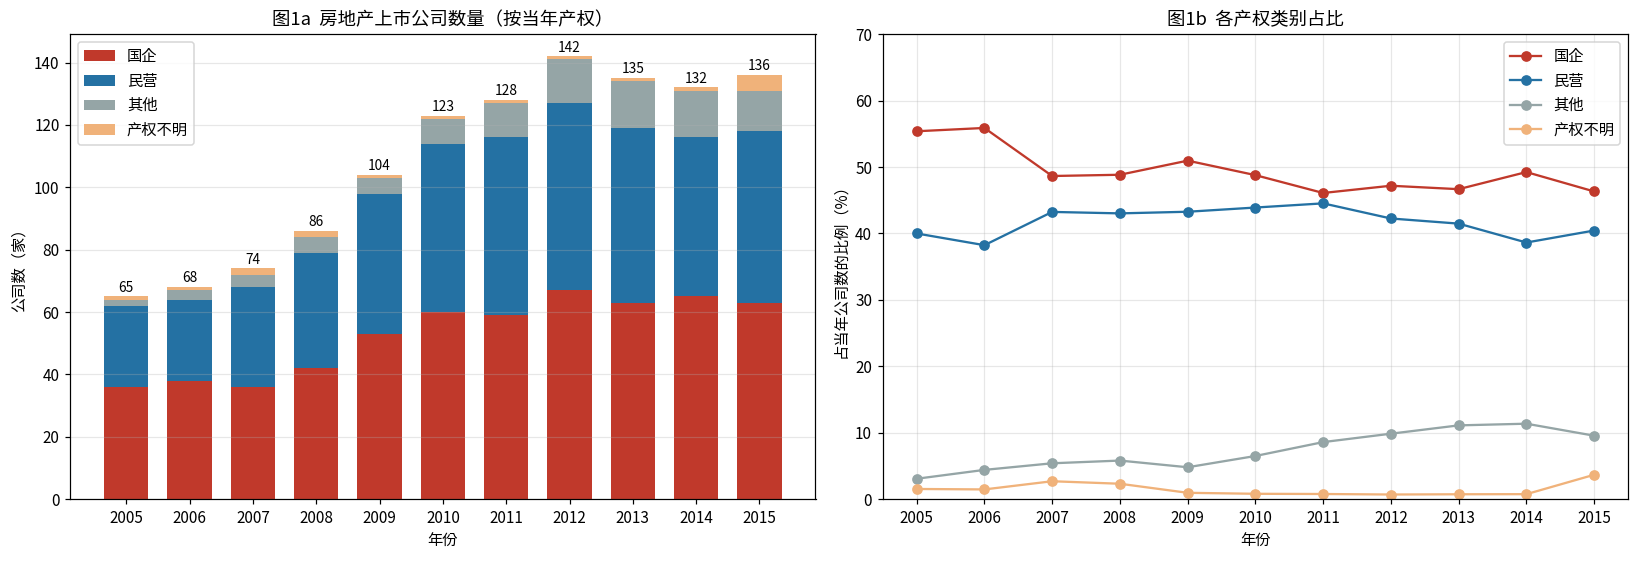

In [7]:
cnt = df.groupby(["year", "own"]).code.nunique().unstack().reindex(columns=["国企", "民营", "其他", "产权不明"]).fillna(0).astype(int)
cnt["合计"] = df.groupby("year").code.nunique()
assert (cnt[["国企", "民营", "其他", "产权不明"]].sum(axis=1) == cnt["合计"]).all()
assert cnt["合计"].sum() == len(df)          # 公司数与样本一致，与指标是否缺失无关
share = cnt[["国企", "民营", "其他", "产权不明"]].div(cnt["合计"], axis=0) * 100
cnt_tab = pd.concat([cnt, share.round(1).add_suffix("占比%")], axis=1)
cnt_tab.to_csv(TAB / "firm_counts_by_ownership.csv", encoding="utf-8-sig")
display(cnt_tab)

COL = {"国企": "#c0392b", "民营": "#2471a3", "其他": "#95a5a6", "产权不明": "#f0b27a"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.2))
bottom = np.zeros(len(cnt))
for g in ["国企", "民营", "其他", "产权不明"]:
    ax1.bar(cnt.index, cnt[g], bottom=bottom, color=COL[g], label=g, width=0.7)
    bottom += cnt[g].values
for x, v in zip(cnt.index, cnt["合计"]):
    ax1.text(x, v + 1.5, str(v), ha="center", fontsize=9)
ax1.set_title("图1a  房地产上市公司数量（按当年产权）"); ax1.set_xlabel("年份"); ax1.set_ylabel("公司数（家）")
ax1.set_xticks(cnt.index); ax1.legend(); ax1.grid(axis="y", alpha=0.3)
for g in ["国企", "民营", "其他", "产权不明"]:
    ax2.plot(share.index, share[g], marker="o", color=COL[g], label=g)
ax2.set_title("图1b  各产权类别占比"); ax2.set_xlabel("年份"); ax2.set_ylabel("占当年公司数的比例（%）")
ax2.set_xticks(share.index); ax2.set_ylim(0, 70); ax2.legend(); ax2.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG / "fig1_counts_ownership.png"); plt.show()

**解读。** 房地产上市公司数从 2005 年的 **65 家**增加到 2012 年的峰值 **142 家**，2015 年为 136 家。其中国企从 36 家增加到 63 家，民营从 26 家增加到 55 家，“其他”从 2 家增加到 13 家（2013—2014 年最多，为 15 家），产权不明在 2015 年增加到 5 家。**国企始终是最大群体**，但它的占比从 55.4% 降到 46.3%；民营占比一直在 38%—45% 之间，2011 年最高（44.5%）；“其他”的占比从 3.1% 升到 9.6%，主要是外资控制的公司增加。每年各类计数之和等于当年的公司总数，总计 1,193，与样本一致，不受任何指标缺失的影响（代码中有 `assert` 校验）。

**核心发现：**
- 公司数量大约翻了一倍，主要来自其他行业公司转入（§4.2）；
- 国企占比下降，一方面因为非国企公司更多地转入，另一方面因为有 11 次国企转为非国企。这是样本构成的变化，不是同一批公司的行为变化。

## 6. 六项财务指标

### 6.1 定义与处理规则

本节按官方公式计算六个比率，并事先规定分母有效性和缺失值的处理规则。

| 指标 | 官方定义 | CSMAR 变量 | 分母有效性 | 缺失处理 |
|---|---|---|---|---|
| 资产负债率 | 总负债 / 总资产 | A002000000 / A001000000 | 总资产 > 0 | 保留缺失 |
| bankloan | (短期银行借款 + 长期银行借款) / 总负债 | (A002101000 + A002201000) / A002000000 | 总负债 > 0 | **任一借款缺失 → 缺失，不补 0** |
| 短期负债占比 | 流动负债 / 总负债 | A002100000 / A002000000 | 总负债 > 0 | 保留缺失 |
| ROA | 合并净利润 / 平均总资产 | B002000000 / [(A001000000ₜ₋₁ + A001000000ₜ)/2] | 两期总资产 > 0 | 缺 t−1 → 缺失 |
| ROE | 合并净利润 / 平均所有者权益 | B002000000 / [(A003000000ₜ₋₁ + A003000000ₜ)/2] | 平均权益 > 0，否则记为缺失并单独报告 | 缺 t−1 → 缺失 |
| Cash_TA | 货币资金 / 总资产 | A001101000 / A001000000 | 总资产 > 0 | 保留缺失 |

- **bankloan 的口径。** CSMAR 没有单列“银行借款”，只能用“短期借款 + 长期借款”作代理。按字段字典，长期借款包括向**其他金融机构**的借款，短期借款也不限于银行，所以这一代理可能**高估**纯银行借款；另一方面，一年内到期的长期借款列在“一年内到期的非流动负债”中，没有计入，又可能**低估**。两个偏差方向相反，净影响无法用现有字段确定。下文统一称为“借款占比（bankloan）”。
- **官方要求区分的口径。** Cash_TA 用**货币资金**，不是“现金及现金等价物”；短期负债占比用**流动负债**，它还包括应付款、预收账款等，**不是**短期银行借款。
- **会计范围一致。** 合并净利润包含少数股东损益，所有者权益合计包含少数股东权益，分子与分母都是合并口径。
- **单位。** 比率以小数计算，只在图表中 ×100 显示为 %。

In [8]:
d = df.copy()
TA, TL, CL, CASH, EQ = d.A001000000, d.A002000000, d.A002100000, d.A001101000, d.A003000000
STB, LTB, NI = d.A002101000, d.A002201000, d.B002000000
checks = pd.Series({
    "总资产 ≤ 0": int((TA <= 0).sum()), "总负债 ≤ 0": int((TL <= 0).sum()),
    "|TA−TL−EQ|/TA > 0.1%": int(((TA - TL - EQ).abs() / TA > 1e-3).sum()),
    "货币资金 > 总资产": int((CASH > TA).sum()), "流动负债 > 总负债": int((CL > TL * (1 + 1e-9)).sum()),
    "短期+长期借款 > 总负债": int(((STB + LTB) > TL * (1 + 1e-9)).sum()),
    "期末权益 ≤ 0": int((EQ <= 0).sum()), "上期余额缺失": int(d.TA_lag.isna().sum())})
display(checks.rename("观测数").to_frame())
display(pd.DataFrame({"缺失": d[NUM_BS + ["B002000000"]].isna().sum(),
                      "等于 0": (d[NUM_BS + ["B002000000"]] == 0).sum()}).T)
print("借款科目缺失的观测（bankloan 保留为缺失）:")
display(d.loc[STB.isna() | LTB.isna(), ["code", "ShortName", "year", "A002101000", "A002201000"]])

d["lev"] = np.where(TA > 0, TL / TA, np.nan)
loans = pd.concat([STB, LTB], axis=1).sum(axis=1, min_count=2)     # 两个科目都非缺失才求和
d["bankloan"] = np.where(TL > 0, loans / TL, np.nan)
d["stdebt"] = np.where(TL > 0, CL / TL, np.nan)
d["avg_ta"], d["avg_eq"] = (TA + d.TA_lag) / 2, (EQ + d.EQ_lag) / 2
d["roa"] = np.where((TA > 0) & (d.TA_lag > 0), NI / d.avg_ta, np.nan)
d["neg_avg_eq"] = d.avg_eq.le(0)
d["roe"] = np.where(d.avg_eq > 0, NI / d.avg_eq, np.nan)
d["cash_ta"] = np.where(TA > 0, CASH / TA, np.nan)
print("平均权益 ≤ 0 → ROE 设为缺失:", int(d.neg_avg_eq.sum()), "个；涉及公司:",
      sorted(d.loc[d.neg_avg_eq, "ShortName"].str.replace(r"^[S\*]*ST ?", "", regex=True).unique()))
d.drop(columns=["own_prev"]).to_csv(PROC / "realestate_panel_2005_2015.csv", index=False, encoding="utf-8-sig")
for v, nm in IND.items():
    ok = d[d[v].notna()]
    FLOW.append({"阶段": "变量构造", "步骤": f"{nm} 有效", "公司-年": len(ok), "公司数": ok.code.nunique()})
flow = pd.DataFrame(FLOW)
flow.to_csv(TAB / "sample_processing_table.csv", index=False, encoding="utf-8-sig")
display(flow)

,观测数
总资产 ≤ 0,0
总负债 ≤ 0,0
|TA−TL−EQ|/TA > 0.1%,6
货币资金 > 总资产,0
流动负债 > 总负债,0
短期+长期借款 > 总负债,0
期末权益 ≤ 0,22
上期余额缺失,9


,A001101000,A001000000,A002101000,A002100000,A002201000,A002000000,A003000000,B002000000
缺失,0,0,0,0,2,0,0,0
等于 0,0,0,258,0,227,0,0,0


借款科目缺失的观测（bankloan 保留为缺失）:


,code,ShortName,year,A002101000,A002201000
323,000638,万方地产,2011,"1,179,900.0000",NaN
852,600606,金丰投资,2008,"988,000,000.0000",NaN


平均权益 ≤ 0 → ROE 设为缺失: 21 个；涉及公司: ['兴业', '园城', '国商', '天华', '天华股份', '昌源', '江纸', '深国商', '珠江控股', '达声A', '零七A']


,阶段,步骤,公司-年,公司数
0,下载,基本信息表,22577,2870
1,下载,股权性质表,22572,2870
2,下载,资产负债表（2004—2015）,24228,3059
3,下载,利润表,22871,3043
4,筛选,基本信息表 2005—2015 全部公司-年,22577,2870
5,筛选,当年行业代码 = K70,1194,172
6,筛选,年末已上市（LISTINGDATE ≤ 年末）,1193,172
7,筛选,年末未终止上市,1193,172
8,筛选,沪深 A 股代码,1193,172
9,合并,匹配股权性质,1193,172


**解读。** 所有合理性检查都通过：没有非正的总资产或总负债，货币资金、流动负债、借款合计都没有超过各自的上限。只有 6 个观测的会计恒等式偏差超过总资产的 0.1%。长期借款缺失的 2 个观测（万方地产 2011、金丰投资 2008）的 bankloan 保留为缺失。另有 258 个短期借款、227 个长期借款是**明确记录的 0**，这是真实的零值，予以保留。22 个公司-年的期末权益 ≤ 0，21 个的平均权益 ≤ 0，集中在 ST兴业、S*ST天华、*ST昌源、深国商等少数公司；对它们，ROE 在经济上没有意义，所以记为缺失。完整的样本处理表显示，六个指标的有效观测分别为 1,193、1,191、1,193、1,184、1,163、1,193。

**核心发现：**
- 缺失值没有被当作 0，零值与缺失值分开处理；
- ROE 的 30 个缺失 = 9 个缺上期余额 + 21 个平均权益 ≤ 0，规则事先定好，并且可以追溯。

### 6.3 年度有效样本量（官方要求）

In [9]:
def n_table(var):
    t = d.groupby(["year", "own"])[var].count().unstack().reindex(columns=["国企", "民营", "其他", "产权不明"]).fillna(0).astype(int)
    t.insert(0, "全部", d.groupby("year")[var].count())
    return t
N_all = pd.concat({IND[v]: n_table(v) for v in IND}, axis=1)
N_all.loc["合计"] = N_all.sum()
N_all.to_csv(TAB / "valid_N_by_indicator_year_ownership.csv", encoding="utf-8-sig")
display(N_all)

资产负债率                    bankloan（借款/总负债）                    短期负债占比                      ROA                      ROE                    Cash_TA（货币资金/总资产）                   
own     全部   国企   民营  其他 产权不明               全部   国企   民营  其他 产权不明     全部   国企   民营  其他 产权不明    全部   国企   民营  其他 产权不明    全部   国企   民营  其他 产权不明                全部   国企   民营  其他 产权不明
year                                                                                                                                                                              
2005    65   36   26   2    1               65   36   26   2    1     65   36   26   2    1    65   36   26   2    1    61   35   24   2    0                65   36   26   2    1
2006    68   38   26   3    1               68   38   26   3    1     68   38   26   3    1    66   36   26   3    1    63   36   24   3    0                68   38   26   3    1
2007    74   36   32   4    2               74   36   32   4    2     74   36   32   4    2    72   36   30   4    2    69   36   28   4    1                74   36   32   4    2
2008    86   42   37   5    2               85   41   37   5    2     86   42   37   5    2    85   42   36   5    2    83   42   35   5    1                86   42   37   5    2
2009   104   53   45   5    1              104   53   45   5    1    104   53   45   5    1   102   53   43   5    1   100   53   41   5    1               104   53   45   5    1
2010   123   60   54   8    1              123   60   54   8    1    123   60   54   8    1   123   60   54   8    1   121   60   52   8    1               123   60   54   8    1
2011   128   59   57  11    1              127   59   56  11    1    128   59   57  11    1   128   59   57  11    1   126   59   55  11    1               128   59   57  11    1
2012   142   67   60  14    1              142   67   60  14    1    142   67   60  14    1   142   67   60  14    1   140   67   58  14    1               142   67   60  14    1
2013   135   63   56  15    1              135   63   56  15    1    135   63   56  15    1   135   63   56  15    1   135   63   56  15    1               135   63   56  15    1
2014   132   65   51  15    1              132   65   51  15    1    132   65   51  15    1   132   65   51  15    1   132   65   51  15    1               132   65   51  15    1
2015   136   63   55  13    5              136   63   55  13    5    136   63   55  13    5   134   62   54  13    5   133   61   54  13    5               136   63   55  13    5
合计    1193  582  499  95   17             1191  581  498  95   17   1193  582  499  95   17  1184  579  493  95   17  1163  577  478  95   13              1193  582  499  95   17

**解读。** 资产负债率、短期负债占比、Cash_TA 每年的有效 N 都等于当年的公司数。bankloan 在 2008、2011 年各少 1 个，ROA 与 ROE 在上市当年和资不抵债的年份有缺失。有效 N 最小的是 2005 年的 ROE：全部 61 个，其中国企 35、民营 24。“其他”与“产权不明”每年只有几个到十几个观测，所以不单独作图，只计入“全部”。

**核心发现：**
- 国企每年有 35—67 个观测，民营 24—60 个。2005—2007 年两组样本都较小，组间比较更容易受个别公司影响；
- 年度公司数（§5）与指标的有效 N 是分开统计的，公司数不会因为指标缺失而减少。

## 7. 离群值检查与处理

本节在作图之前，检查每个指标的分布与极端值，并决定处理方式。原则是：只有定义上无意义的值才设为缺失，**不为了让图更好看而删除数据**。

- 看分位数（p0、p1、p5、p25、p50、p75、p95、p99、p100）与偏度；
- 标记经济上不可能或可疑的观测，追溯到具体公司；
- 用全样本 1%/99% 缩尾做敏感性分析，比较它对均值以及对国企−民营差异方向的影响。

,N,均值,p0,p1,p5,p25,p50,p75,p95,p99,p100,偏度
资产负债率,1193,0.7248,0.0282,0.1409,0.2622,0.4947,0.6451,0.7454,0.8716,1.6661,55.4086,25.0139
bankloan（借款/总负债）,1191,0.3239,0.0000,0.0000,0.0000,0.1766,0.3162,0.4565,0.6855,0.8043,0.9157,0.2683
短期负债占比,1193,0.7377,0.1197,0.2478,0.3950,0.6166,0.7470,0.8806,1.0000,1.0000,1.0000,-0.5223
ROA,1184,0.0340,-1.5424,-0.1565,-0.0526,0.0121,0.0293,0.0504,0.1062,0.2065,2.2450,7.4167
ROE,1163,0.0919,-5.2679,-0.4364,-0.1060,0.0331,0.0883,0.1503,0.2736,0.5354,4.3193,-2.8469
Cash_TA（货币资金/总资产）,1193,0.1374,0.0002,0.0035,0.0178,0.0642,0.1175,0.1767,0.3508,0.4942,0.8290,1.8909


,观测数
资产负债率 > 100%,22
bankloan > 100%,0
短期负债占比 > 100%,0
Cash_TA > 100%,0
|ROA| > 20%,20
|ROE| > 50%,20
平均权益 ≤ 0（ROE 缺失）,21
0 < 平均权益 < 5% 平均总资产（分母过小）,4


===== 资产负债率 极端观测


,code,ShortName,year,own,lev,总资产亿,总负债亿,权益亿,上期权益亿,净利润亿,尾部
379,000711,*ST 京蓝,2015,民营,0.0282,2.9762,0.0839,2.8923,3.1833,-0.1001,最小
256,000567,海德股份,2015,民营,0.0463,2.2899,0.1061,2.1838,2.3758,0.2323,最小
349,000670,S*ST 天发,2008,民营,0.0675,2.4191,0.1634,2.2557,2.0002,0.0560,最小
864,600615,丰华股份,2012,民营,0.0704,5.3289,0.3750,4.9538,4.9128,0.0410,最小
1181,600890,中房股份,2015,产权不明,0.0977,3.6514,0.3569,3.2946,3.1732,0.1213,最小
843,600603,ST 兴业,2009,民营,55.4086,0.0496,2.7505,-2.7008,-2.7324,0.0316,最大
842,600603,ST 兴业,2008,产权不明,18.1410,0.1594,2.8918,-2.7324,-3.0437,0.3190,最大
1071,600745,S*ST 天华,2007,民营,12.2384,0.1477,1.8079,-1.6602,-2.2918,0.4603,最大
841,600603,ST 兴业,2007,产权不明,9.7652,0.3472,3.3909,-3.0437,-3.8557,0.8121,最大
1070,600745,S*ST 天华,2006,民营,9.7366,0.2623,2.5541,-2.2918,-2.3735,-0.1123,最大


===== ROA 极端观测


,code,ShortName,year,own,roa,总资产亿,总负债亿,权益亿,上期权益亿,净利润亿,尾部
1069,600745,天华股份,2005,民营,-1.5424,0.2729,2.6464,-2.3735,0.0842,-2.3884,最小
1070,600745,S*ST 天华,2006,民营,-0.4195,0.2623,2.5541,-2.2918,-2.3735,-0.1123,最小
268,000592,*ST 昌源,2005,民营,-0.4111,2.5307,6.8916,-4.3609,-1.4795,-1.5665,最小
1171,600890,中房股份,2005,国企,-0.2771,6.1160,2.3990,3.7170,6.2063,-2.5267,最小
882,600634,海鸟发展,2009,民营,-0.2563,2.1099,0.6174,1.4925,2.1364,-0.6082,最小
1071,600745,S*ST 天华,2007,民营,2.2450,0.1477,1.8079,-1.6602,-2.2918,0.4603,最大
270,000592,S*ST 昌源,2007,民营,1.6965,1.7657,3.1970,-1.4313,-5.2177,3.7833,最大
842,600603,ST 兴业,2008,产权不明,1.2593,0.1594,2.8918,-2.7324,-3.0437,0.3190,最大
841,600603,ST 兴业,2007,产权不明,1.0065,0.3472,3.3909,-3.0437,-3.8557,0.8121,最大
129,000056,*ST 国商,2013,民营,0.7897,78.0328,43.3497,34.6831,-4.0503,38.7334,最大


===== ROE 极端观测


,code,ShortName,year,own,roe,总资产亿,总负债亿,权益亿,上期权益亿,净利润亿,尾部
1111,600766,园城股份,2010,民营,-5.2679,4.4301,4.7637,-0.3335,0.7031,-0.9735,最小
174,000505,珠江控股,2014,国企,-2.4589,16.4544,16.2638,0.1906,1.2797,-1.8076,最小
27,000007,深达声A,2006,民营,-1.5863,8.0588,7.8875,0.1713,1.0850,-0.9964,最小
308,000628,高新发展,2007,国企,-1.0311,18.7227,17.3807,1.3420,4.1024,-2.8068,最小
1109,600766,园城股份,2008,民营,-0.7948,5.6804,4.8794,0.8009,1.8572,-1.0563,最小
1045,600734,ST 实达,2008,民营,4.3193,13.6982,11.9219,1.7763,-1.0462,1.5767,最大
129,000056,*ST 国商,2013,民营,2.5289,78.0328,43.3497,34.6831,-4.0503,38.7334,最大
1072,600745,ST 天华,2008,民营,1.9829,16.4414,13.0717,3.3697,-1.6602,1.6948,最大
28,000007,ST 达声A,2007,民营,1.9795,7.3718,7.4554,-0.0836,0.1713,0.0868,最大
470,000979,中弘地产,2010,民营,1.1779,55.0777,37.4090,17.6687,-2.1886,9.1170,最大


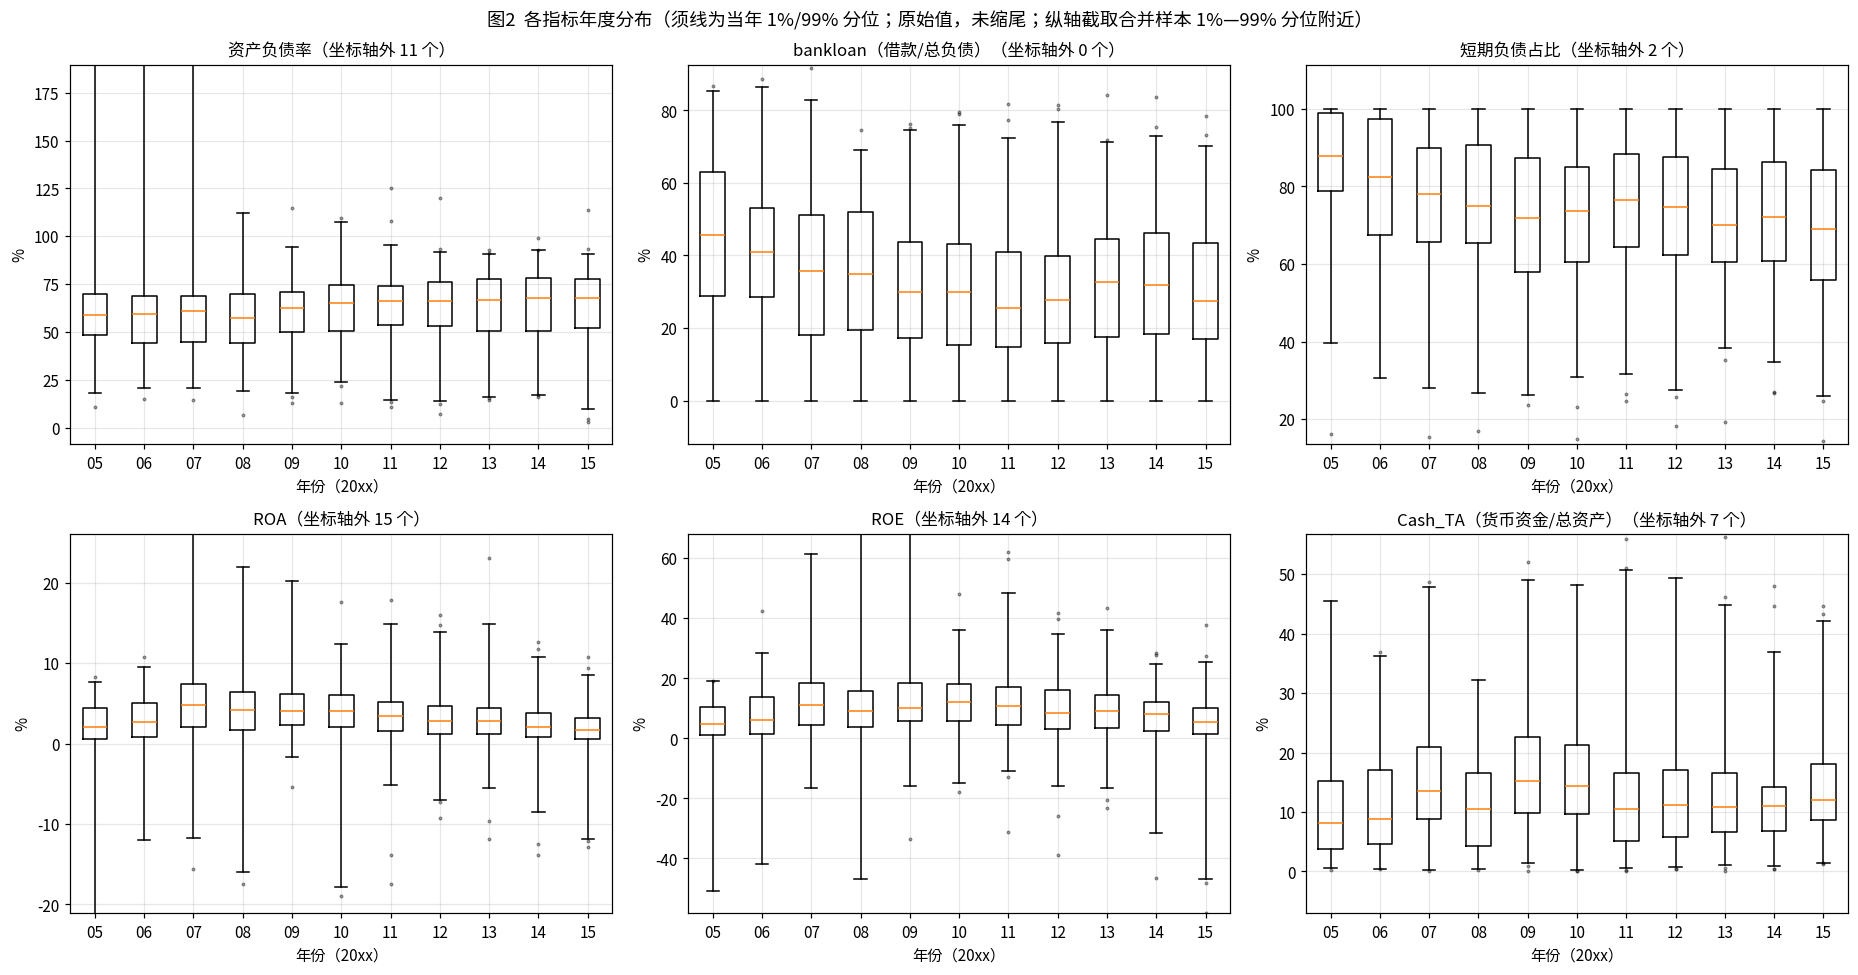

In [10]:
qs = [0, .01, .05, .25, .5, .75, .95, .99, 1]
dist = d[list(IND)].quantile(qs).T
dist.columns = [f"p{int(q*100)}" for q in qs]
dist.insert(0, "N", d[list(IND)].count()); dist.insert(1, "均值", d[list(IND)].mean())
dist["偏度"] = d[list(IND)].skew()
dist = dist.rename(index=IND)
dist.to_csv(TAB / "pooled_distribution.csv", encoding="utf-8-sig")
display(dist)
flags = pd.Series({"资产负债率 > 100%": int((d.lev > 1).sum()), "bankloan > 100%": int((d.bankloan > 1).sum()),
                   "短期负债占比 > 100%": int((d.stdebt > 1).sum()), "Cash_TA > 100%": int((d.cash_ta > 1).sum()),
                   "|ROA| > 20%": int((d.roa.abs() > 0.2).sum()), "|ROE| > 50%": int((d.roe.abs() > 0.5).sum()),
                   "平均权益 ≤ 0（ROE 缺失）": int(d.neg_avg_eq.sum()),
                   "0 < 平均权益 < 5% 平均总资产（分母过小）": int(((d.avg_eq > 0) & (d.avg_eq < 0.05 * d.avg_ta)).sum())})
display(flags.rename("观测数").to_frame())

def extremes(var, n=5):
    cols = ["code", "ShortName", "year", "own", var, "A001000000", "A002000000", "A003000000", "EQ_lag", "B002000000"]
    out = pd.concat([d.nsmallest(n, var)[cols].assign(尾部="最小"), d.nlargest(n, var)[cols].assign(尾部="最大")])
    for c in cols[5:]:
        out[c] = out[c] / 1e8
    return out.rename(columns={"A001000000": "总资产亿", "A002000000": "总负债亿", "A003000000": "权益亿", "EQ_lag": "上期权益亿", "B002000000": "净利润亿"})
for v in ["lev", "roa", "roe"]:
    print(f"===== {IND[v]} 极端观测"); display(extremes(v))
pd.concat([extremes(v).assign(指标=IND[v]) for v in IND]).to_csv(QA / "extreme_observations.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
years = list(range(Y0, Y1 + 1))
for ax, v in zip(axes.flat, IND):
    ax.boxplot([100 * d.loc[d.year == y, v].dropna().values for y in years], tick_labels=[str(y)[2:] for y in years],
               whis=(1, 99), flierprops=dict(marker=".", markersize=3, alpha=0.5))
    lo, hi = np.nanpercentile(100 * d[v], [1, 99]); pad = (hi - lo) * 0.15
    ax.set_ylim(lo - pad, hi + pad)
    n_out = int(((100 * d[v] < lo - pad) | (100 * d[v] > hi + pad)).sum())
    ax.set_title(f"{IND[v]}（坐标轴外 {n_out} 个）", fontsize=11)
    ax.set_xlabel("年份（20xx）"); ax.set_ylabel("%"); ax.grid(alpha=0.3)
fig.suptitle("图2  各指标年度分布（须线为当年 1%/99% 分位；原始值，未缩尾；纵轴截取合并样本 1%—99% 分位附近）", fontsize=12)
fig.tight_layout(); fig.savefig(FIG / "fig2_boxplots_by_year.png"); plt.show()

**解读。** 三个有界指标（bankloan、短期负债占比、Cash_TA）都落在 [0, 1] 内，没有异常值。三个无界指标则有明显的极端值：
- **资产负债率：** 22 个观测超过 100%，最高 5,541%（ST兴业 2009，总资产 0.05 亿元，总负债 2.75 亿元）；
- **ROA：** 从 −154% 到 +224%，极端值来自总资产只有 0.15—0.36 亿元的壳公司，例如 S*ST天华 2007 年靠债务重组收益实现盈利；
- **ROE：** 从 −527% 到 +432%，来自平均权益为正但接近 0 的情形，例如园城股份 2010 年平均权益仅 0.18 亿元。

这些观测会计恒等式成立，也能追溯到具体公司的财务困境，不是录入错误。删掉它们会美化行业的财务状况，所以**主结果保留原始值**，解读时以中位数为主，并用缩尾做敏感性分析。

**核心发现：**
- 离群值集中在少数 ST 壳公司，影响的是资产负债率、ROA、ROE 这三个无界指标；
- 处理规则：只在平均权益 ≤ 0 时把 ROE 设为缺失（定义上无意义）；其他观测一律保留，并同时报告均值与中位数。

,原始均值−中位数（11年平均，百分点）,|原始均值−缩尾均值| 最大（百分点）,最大差异年份,缩尾改变的观测数,国企−民营均值差方向改变的年数
资产负债率,11.4711,51.6648,"2,009.0000",24.0000,2.0000
bankloan（借款/总负债）,0.6099,0.2593,"2,006.0000",12.0000,0.0000
短期负债占比,-1.0276,0.1885,"2,006.0000",12.0000,0.0000
ROA,0.3571,6.0118,"2,007.0000",24.0000,1.0000
ROE,0.5458,5.8323,"2,008.0000",24.0000,2.0000
Cash_TA（货币资金/总资产）,2.1664,0.3890,"2,008.0000",24.0000,0.0000


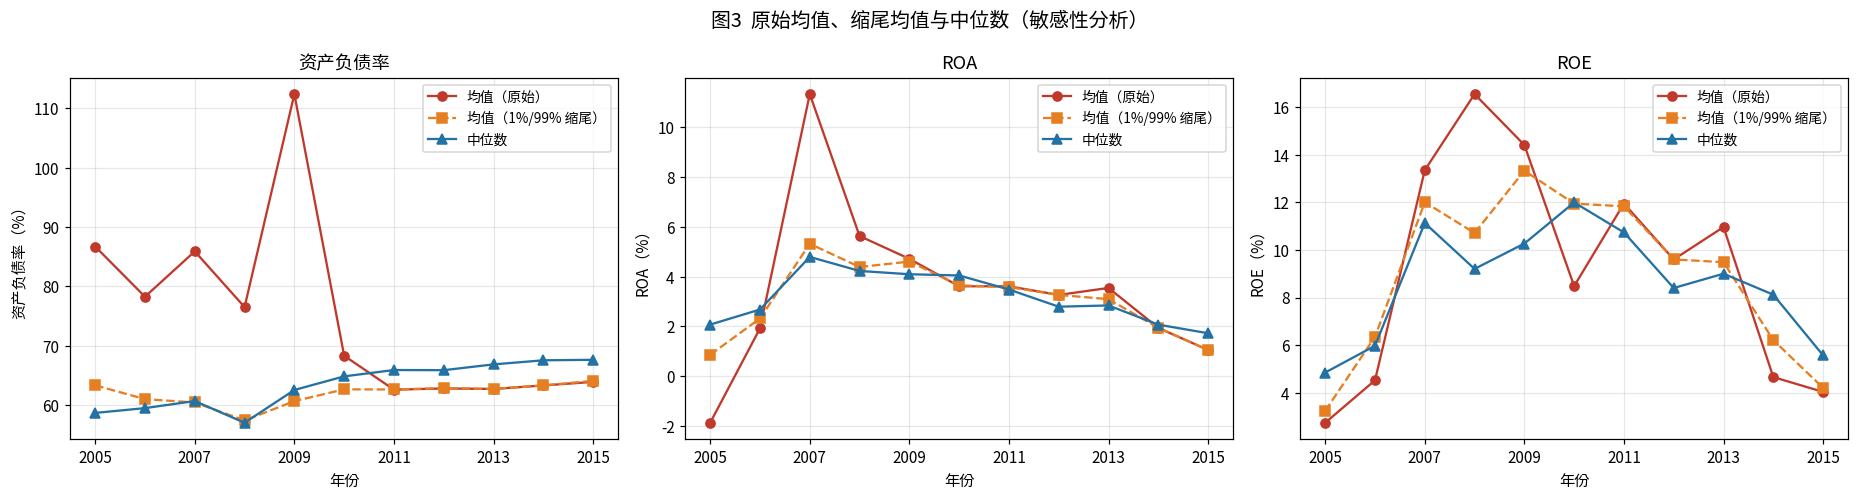

In [11]:
def winsor(s, p=0.01):
    lo, hi = s.quantile([p, 1 - p]); return s.clip(lo, hi)
for v in IND:
    d[v + "_w"] = winsor(d[v])
def gdiff(col, stat="mean"):
    return getattr(d[d.own == "国企"].groupby("year")[col], stat)() - getattr(d[d.own == "民营"].groupby("year")[col], stat)()
sens = pd.DataFrame({IND[v]: {
    "原始均值−中位数（11年平均，百分点）": 100 * (d.groupby("year")[v].mean() - d.groupby("year")[v].median()).mean(),
    "|原始均值−缩尾均值| 最大（百分点）": 100 * (d.groupby("year")[v].mean() - d.groupby("year")[v + "_w"].mean()).abs().max(),
    "最大差异年份": int((d.groupby("year")[v].mean() - d.groupby("year")[v + "_w"].mean()).abs().idxmax()),
    "缩尾改变的观测数": int(((d[v] != d[v + "_w"]) & d[v].notna()).sum()),
    "国企−民营均值差方向改变的年数": int((np.sign(gdiff(v)) != np.sign(gdiff(v + "_w"))).sum())} for v in IND}).T
sens.to_csv(TAB / "sensitivity_winsor.csv", encoding="utf-8-sig")
display(sens)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, v in zip(axes, ["lev", "roa", "roe"]):
    g = d.groupby("year")
    ax.plot(g[v].mean().index, 100 * g[v].mean(), "o-", color="#c0392b", label="均值（原始）")
    ax.plot(g[v].mean().index, 100 * g[v + "_w"].mean(), "s--", color="#e67e22", label="均值（1%/99% 缩尾）")
    ax.plot(g[v].mean().index, 100 * g[v].median(), "^-", color="#2471a3", label="中位数")
    ax.set_title(f"{IND[v]}"); ax.set_xlabel("年份"); ax.set_ylabel(f"{IND[v]}（%）")
    ax.set_xticks(range(Y0, Y1 + 1, 2)); ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.suptitle("图3  原始均值、缩尾均值与中位数（敏感性分析）", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "fig3_sensitivity.png"); plt.show()

**解读。** 缩尾对资产负债率均值的影响最大可达 51.7 个百分点（2009 年），国企−民营均值差有 2 年改变方向；ROA 与 ROE 的最大影响分别为 6.0 个百分点（2007）和 5.8 个百分点（2008），方向分别改变 1 年和 2 年。三个有界指标的最大影响不超过 0.39 个百分点，方向没有任何改变。从图 3 看，缩尾后资产负债率的均值几乎与中位数重合。

**核心发现：**
- 2005—2009 年资产负债率、ROA、ROE 的**均值**由离群值主导，基于这些均值的组间比较不可靠；
- 中位数与缩尾均值给出的结论一致，所以下文以中位数作为主要依据；有界指标的均值与中位数都可以使用。

## 8. 官方要求的图表

本节按官方要求画出每个指标的三类图：全部公司的均值与中位数、国企 vs 民营的均值、国企 vs 民营的中位数。统计量是**公司比率的算术均值与中位数**，例如资产负债率的均值不是“行业总负债 / 行业总资产”。图中数值都是未缩尾的原始值，单位为 %。

- 图 4：全部公司（含其他与产权不明）的均值与中位数；
- 图 5、图 6：只比较国企与民营，图例中注明各年有效 N 的范围；
- 数据表与图并列展示，方便核对。

资产负债率              bankloan（借款/总负债）               短期负债占比                  ROA                 ROE              Cash_TA（货币资金/总资产）             
          均值%    中位数%    N              均值%    中位数%    N     均值%    中位数%    N     均值%   中位数%    N     均值%    中位数%    N               均值%    中位数%    N
year                                                                                                                                                 
2005  86.7200 58.7300   65          44.0400 45.6600   65 84.7500 87.7800   65 -1.8700 2.0800   65  2.7400  4.8500   61           11.6500  8.1000   65
2006  78.2800 59.5300   68          41.3300 40.9700   68 78.4100 82.4700   68  1.9200 2.6800   66  4.5200  5.9700   63           11.0300  8.7500   68
2007  85.9100 60.7200   74          35.9300 35.7500   74 75.9200 78.1600   74 11.3300 4.7900   72 13.3500 11.1300   69           15.6000 13.4800   74
2008  76.5300 57.0700   86          34.6000 34.8400   85 75.0400 75.0100   86  5.6300 4.2300   85 16.5400  9.2000   83           12.0200 10.5600   86
2009 112.3700 62.5900  104          31.8800 29.8100  104 70.3100 71.7500  104  4.7200 4.1000  102 14.4100 10.2700  100           17.2600 15.2400  104
2010  68.3500 64.8700  123          31.0900 29.8200  123 71.8900 73.7200  123  3.6200 4.0500  123  8.4800 11.9900  121           16.2000 14.3200  123
2011  62.6400 65.9400  128          28.0800 25.5600  127 75.6900 76.5300  128  3.6200 3.4900  128 11.9500 10.7300  126           13.1900 10.4500  128
2012  62.8400 65.9200  142          28.4900 27.8500  142 74.2100 74.5600  142  3.2700 2.8000  142  9.6000  8.4000  140           13.6900 11.1700  142
2013  62.7600 66.8900  135          31.8700 32.6400  135 71.8600 70.1100  135  3.5500 2.8500  135 10.9600  9.0000  135           13.2300 10.8800  135
2014  63.3500 67.5800  132          31.4800 31.9100  132 72.7400 72.2200  132  1.9400 2.0700  132  4.6600  8.1200  132           11.6500 11.0000  132
2015  63.9400 67.6600  136          30.1000 27.3600  136 69.2500 69.0700  136  1.0600 1.7300  134  4.0400  5.5700  133           14.3600 12.0900  136

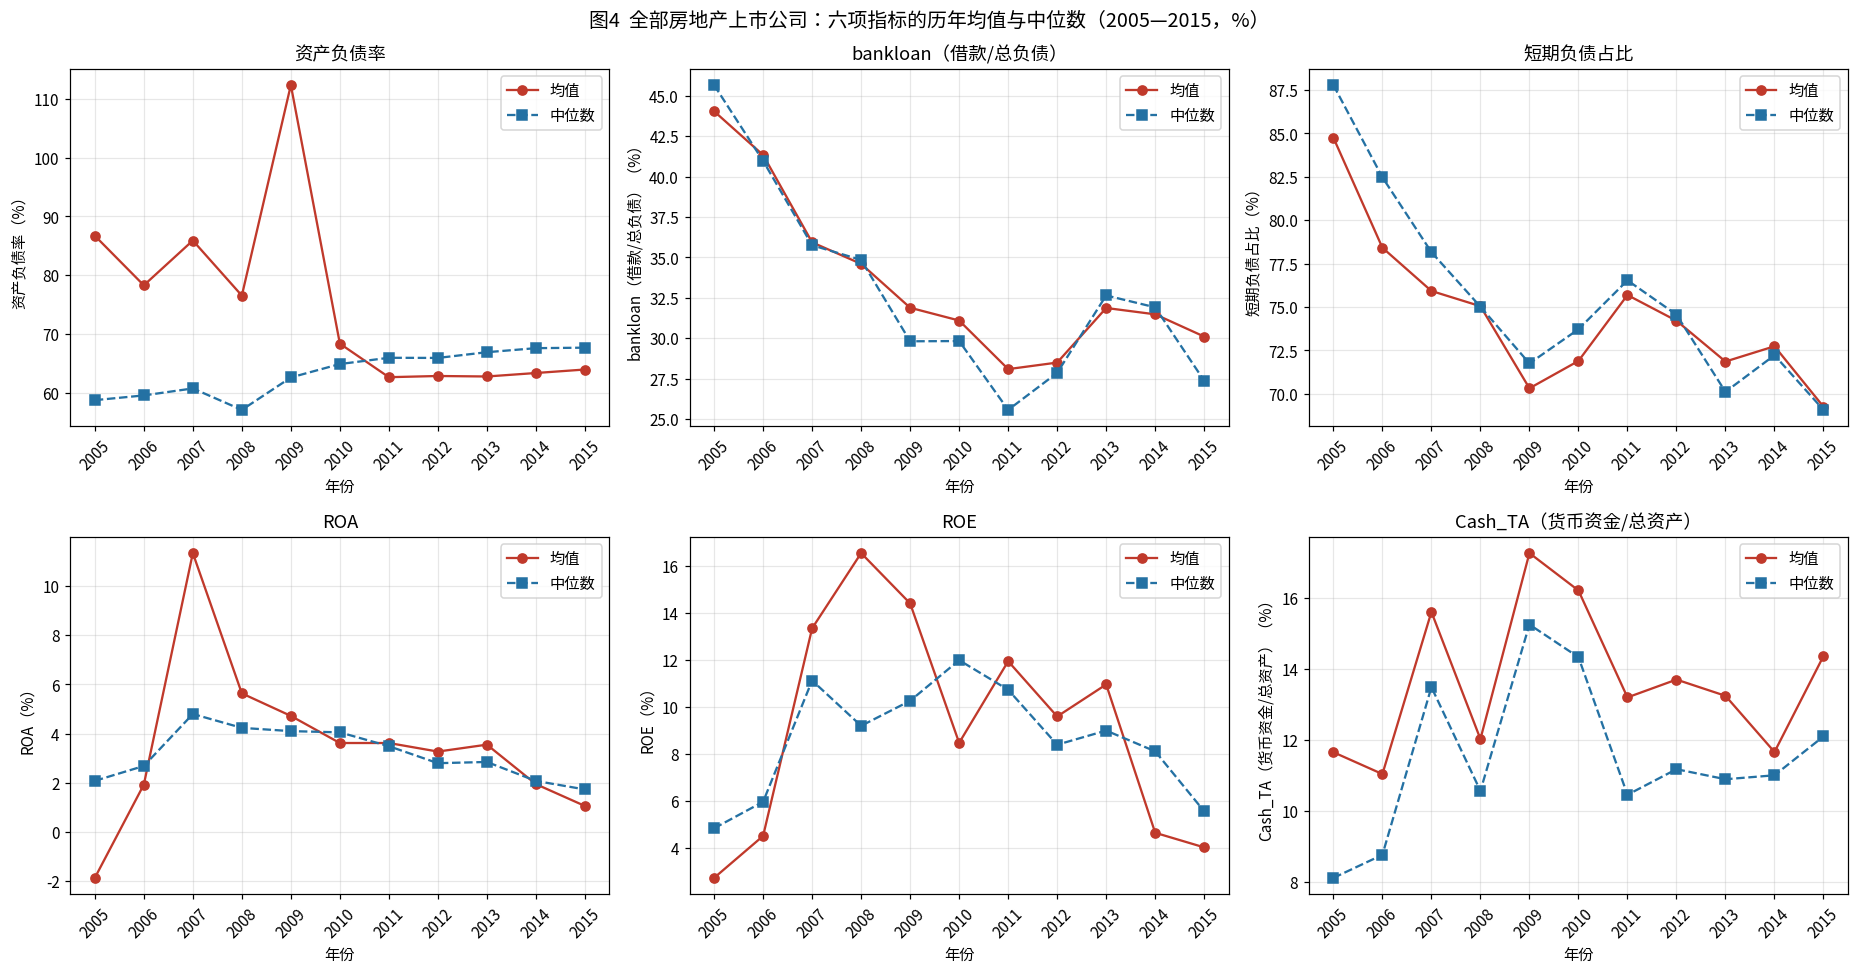

In [12]:
g_all = d.groupby("year")
stat_all = pd.concat({IND[v]: pd.DataFrame({"均值%": 100 * g_all[v].mean(), "中位数%": 100 * g_all[v].median(), "N": g_all[v].count()}) for v in IND}, axis=1)
stat_all.to_csv(TAB / "all_firms_mean_median.csv", encoding="utf-8-sig")
display(stat_all.round(2))
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, v in zip(axes.flat, IND):
    ax.plot(g_all[v].mean().index, 100 * g_all[v].mean(), "o-", color="#c0392b", label="均值")
    ax.plot(g_all[v].median().index, 100 * g_all[v].median(), "s--", color="#2471a3", label="中位数")
    ax.set_title(IND[v]); ax.set_xlabel("年份"); ax.set_ylabel(f"{IND[v]}（%）")
    ax.set_xticks(range(Y0, Y1 + 1)); ax.tick_params(axis="x", labelrotation=45); ax.grid(alpha=0.3); ax.legend()
fig.suptitle("图4  全部房地产上市公司：六项指标的历年均值与中位数（2005—2015，%）", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "fig4_all_mean_median.png"); plt.show()

**解读。** 用中位数衡量：
- **资产负债率**从 58.7%（2005）升到 67.7%（2015），2010 年以后逐年走高。
- **bankloan** 从 45.7% 降到 25.6%（2011）的低点，2015 年为 27.4%。
- **短期负债占比**从 87.8% 降到 69.1%。它一直偏高，这与“预收房款计入流动负债”的行业特点相符。
- **ROA** 在 2007 年达到 4.8% 的高点，2015 年降到 1.7%；**ROE** 在 2010 年达到 12.0% 的高点，2015 年降到 5.6%。
- **Cash_TA** 从 8.1% 升到 2009 年的 15.2%，2015 年为 12.1%。

均值与中位数的差距：
- 资产负债率的均值在 2005—2009 年比中位数高约 19—50 个百分点（2009 年为 112.4% 对 62.6%），这是 ST 壳公司造成的；2011 年以后，均值反而比中位数低 3—4 个百分点。
- ROA 均值在 2007 年为 11.3%（中位数 4.8%），ROE 均值在 2008 年为 16.5%（中位数 9.2%），都是离群值的结果。
- bankloan、短期负债占比、Cash_TA 的均值与中位数接近。

2009—2010 年盈利和现金的高点与金融危机后的信贷宽松同步，2014—2015 年的下滑与房地产市场的调整同步，但这只是时间上的对应，不是因果检验。

**核心发现：**
- 杠杆上升、债务期限拉长、借款占比下降、盈利先升后降；
- 均值与中位数的背离主要出现在资产负债率、ROA、ROE 这三个无界指标上，而且集中在 2005—2009 年。

国企 vs 民营：年度均值（%）


资产负债率                    bankloan（借款/总负债）                  短期负债占比                     ROA                      ROE                  Cash_TA（货币资金/总资产）                
          国企       民营     国企−民营               国企      民营   国企−民营      国企      民营    国企−民营     国企      民营    国企−民营      国企      民营    国企−民营                国企      民营   国企−民营
year                                                                                                                                                                        
2005 58.1300 102.0600  -43.9300          45.5900 43.7100  1.8700 85.7200 86.9100  -1.1800 1.2800 -6.8000   8.0800  2.8000  2.0400   0.7600           14.6800  7.1900  7.4900
2006 56.7100  99.9000  -43.1900          42.3300 43.2300 -0.9000 76.4700 82.7700  -6.2900 2.8400  0.1500   2.6900  7.4300 -0.7300   8.1600           13.0000  8.2800  4.7200
2007 55.6700  97.4700  -41.8100          40.8100 29.7000 11.1100 73.1500 83.1100  -9.9600 3.9000 17.9700 -14.0700  7.5700 20.3200 -12.7400           15.9100 13.9600  1.9500
2008 59.0100  54.3900    4.6200          34.9200 33.0500  1.8700 74.6600 79.1700  -4.5100 3.5800  4.8100  -1.2300  8.8500 27.1100 -18.2600           12.3200  9.7100  2.6100
2009 62.9300 177.9300 -115.0000          32.9800 28.9700  4.0100 71.4900 70.8900   0.6000 4.8600  4.5300   0.3300 15.7500 13.2500   2.4900           18.2100 15.9300  2.2800
2010 65.6100  72.2900   -6.6800          33.4300 27.5100  5.9200 71.9800 73.5600  -1.5800 3.8100  3.3000   0.5100 12.2300  3.7300   8.5000           17.1000 15.8300  1.2700
2011 65.2500  59.9000    5.3500          30.3500 24.7200  5.6400 75.2800 76.6300  -1.3500 3.8200  3.0800   0.7300 11.6700 11.6800  -0.0100           14.7700 11.7000  3.0700
2012 64.7200  61.1400    3.5800          30.2300 25.9200  4.3100 76.0400 75.0900   0.9500 3.4300  2.9600   0.4700  9.6200  9.4500   0.1700           15.8600 12.5500  3.3200
2013 65.3800  59.8600    5.5300          34.3800 28.0600  6.3200 70.5300 75.0500  -4.5200 3.4300  4.0000  -0.5700  9.4400 13.6100  -4.1700           16.3600 10.0400  6.3200
2014 65.1000  61.5600    3.5500          30.1900 31.6600 -1.4700 72.5300 74.8600  -2.3400 2.3400  1.2700   1.0600  3.6300  5.0100  -1.3700           13.6500  9.6300  4.0200
2015 67.5100  61.0800    6.4300          31.4600 28.7400  2.7200 64.2500 74.3000 -10.0500 1.3500  0.4200   0.9300  3.7300  3.4200   0.3100           14.1000 14.2700 -0.1700

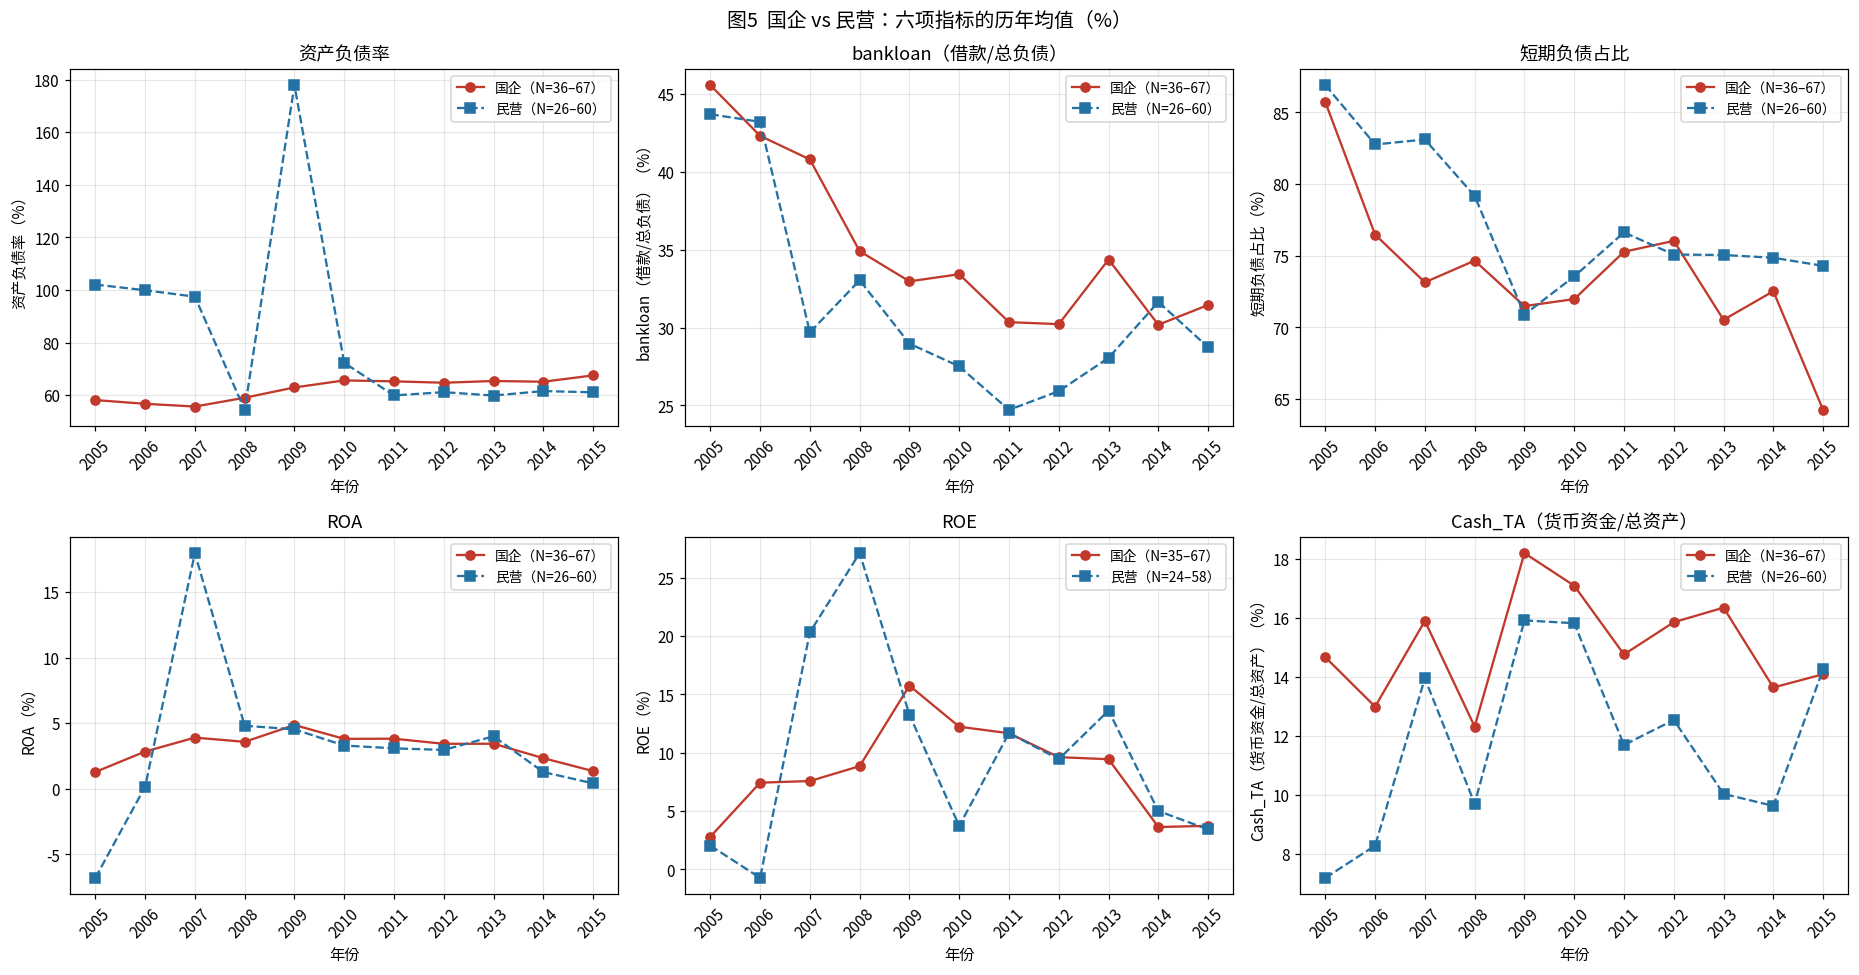

In [13]:
def by_own(stat):
    t = d[d.own.isin(["国企", "民营"])].groupby(["year", "own"])[list(IND)]
    out = (100 * getattr(t, stat)()).unstack()
    res = {}
    for v in IND:
        res[(IND[v], "国企")] = out[(v, "国企")]; res[(IND[v], "民营")] = out[(v, "民营")]
        res[(IND[v], "国企−民营")] = out[(v, "国企")] - out[(v, "民营")]
    return pd.DataFrame(res)
mean_own, med_own = by_own("mean"), by_own("median")
mean_own.to_csv(TAB / "soe_private_mean.csv", encoding="utf-8-sig"); med_own.to_csv(TAB / "soe_private_median.csv", encoding="utf-8-sig")
print("国企 vs 民营：年度均值（%）"); display(mean_own.round(2))

def own_plot(stat, title, fname):
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    for ax, v in zip(axes.flat, IND):
        for gname, sty in [("国企", "o-"), ("民营", "s--")]:
            gg = d[d.own == gname].groupby("year")[v]
            ax.plot(getattr(gg, stat)().index, 100 * getattr(gg, stat)(), sty, color=COL[gname],
                    label=f"{gname}（N={gg.count().min()}–{gg.count().max()}）")
        ax.set_title(IND[v]); ax.set_xlabel("年份"); ax.set_ylabel(f"{IND[v]}（%）")
        ax.set_xticks(range(Y0, Y1 + 1)); ax.tick_params(axis="x", labelrotation=45); ax.grid(alpha=0.3); ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=13); fig.tight_layout(); fig.savefig(FIG / fname); plt.show()
own_plot("mean", "图5  国企 vs 民营：六项指标的历年均值（%）", "fig5_soe_private_mean.png")

**解读。** 从均值看：
- **资产负债率：** 民营组的均值在 2005—2007 年约为 100%，2009 年为 177.9%，由少数资不抵债的民营 ST 公司主导；2011—2015 年国企均值每年都比民营高 3.5—6.4 个百分点。
- **bankloan：** 国企均值 11 年中有 9 年高于民营。
- **短期负债占比：** 国企均值 11 年中有 9 年低于民营，2015 年差距为 −10.1 个百分点。
- **Cash_TA：** 国企均值 11 年中有 10 年高于民营。
- **ROA 与 ROE：** 民营组均值在 2005、2007、2008 年剧烈跳动（例如 2008 年 ROE 为 27.1%），2009 年以后两组的 ROA 差距在 ±1.1 个百分点以内。

**核心发现：**
- 有界指标的均值差异方向稳定：国企借款更多、短期负债更少、现金更多；
- 资产负债率、ROA、ROE 的均值比较在 2005—2009 年被离群值扭曲，需要看中位数（下一节）。

国企 vs 民营：年度中位数（%）


资产负债率                 bankloan（借款/总负债）                  短期负债占比                     ROA                    ROE                 Cash_TA（货币资金/总资产）               
          国企      民营   国企−民营               国企      民营   国企−民营      国企      民营    国企−民营     国企     民营   国企−民营      国企      民营   国企−民营                国企      民营  国企−民营
year                                                                                                                                                                 
2005 56.1200 61.3300 -5.2000          49.9200 39.9100 10.0200 88.6300 93.4000  -4.7800 2.8800 0.9600  1.9200  8.1800  3.4300  4.7500           11.7400  5.4000 6.3400
2006 62.2200 57.1300  5.1000          43.8000 41.8400  1.9600 77.7300 86.1900  -8.4600 2.9800 1.4800  1.5100  7.8100  4.2600  3.5600           11.0300  5.8900 5.1400
2007 59.9200 59.4200  0.5000          43.7400 28.1400 15.6000 75.3200 84.2200  -8.9000 5.0600 4.3200  0.7400 10.6800 12.6800 -2.0000           13.3900 13.3800 0.0100
2008 62.0100 52.8600  9.1400          35.7300 30.2100  5.5200 73.0600 80.3700  -7.3100 3.8600 4.4400 -0.5800  8.7300 10.2700 -1.5400           13.3800  7.8600 5.5100
2009 64.7500 58.5900  6.1600          32.0600 27.6200  4.4500 72.1100 72.3800  -0.2700 4.1100 3.8100  0.3000 12.0000  8.4500  3.5600           16.9500 11.5900 5.3600
2010 68.2800 59.4200  8.8600          36.0800 25.2800 10.8000 73.6900 75.7700  -2.0700 3.7800 4.4600 -0.6700 11.6200 13.6100 -1.9900           15.1500 13.2200 1.9300
2011 68.4600 61.5600  6.8900          31.5600 21.9300  9.6300 75.7700 79.3000  -3.5200 3.6600 2.9900  0.6700 11.5200  9.3600  2.1500           12.2300  7.9900 4.2300
2012 67.6400 65.7900  1.8400          32.6300 24.5900  8.0400 74.4100 78.0900  -3.6700 2.8000 2.6200  0.1700  8.6000  8.0000  0.6000           13.0100  8.7400 4.2700
2013 68.2800 64.4700  3.8100          37.0300 28.4600  8.5700 68.3700 75.1500  -6.7800 2.8800 2.8700  0.0100  9.6400  8.1000  1.5400           13.9500  7.8300 6.1100
2014 69.4000 64.5200  4.8800          31.6100 30.2200  1.4000 72.1100 77.6500  -5.5300 2.4100 1.6800  0.7300  8.9600  6.6100  2.3500           11.8000  8.5700 3.2300
2015 69.4400 66.0600  3.3800          31.1100 26.5200  4.5900 63.5100 77.9200 -14.4100 1.8100 1.4400  0.3700  6.0500  4.6600  1.3900           12.0000 11.8100 0.1900

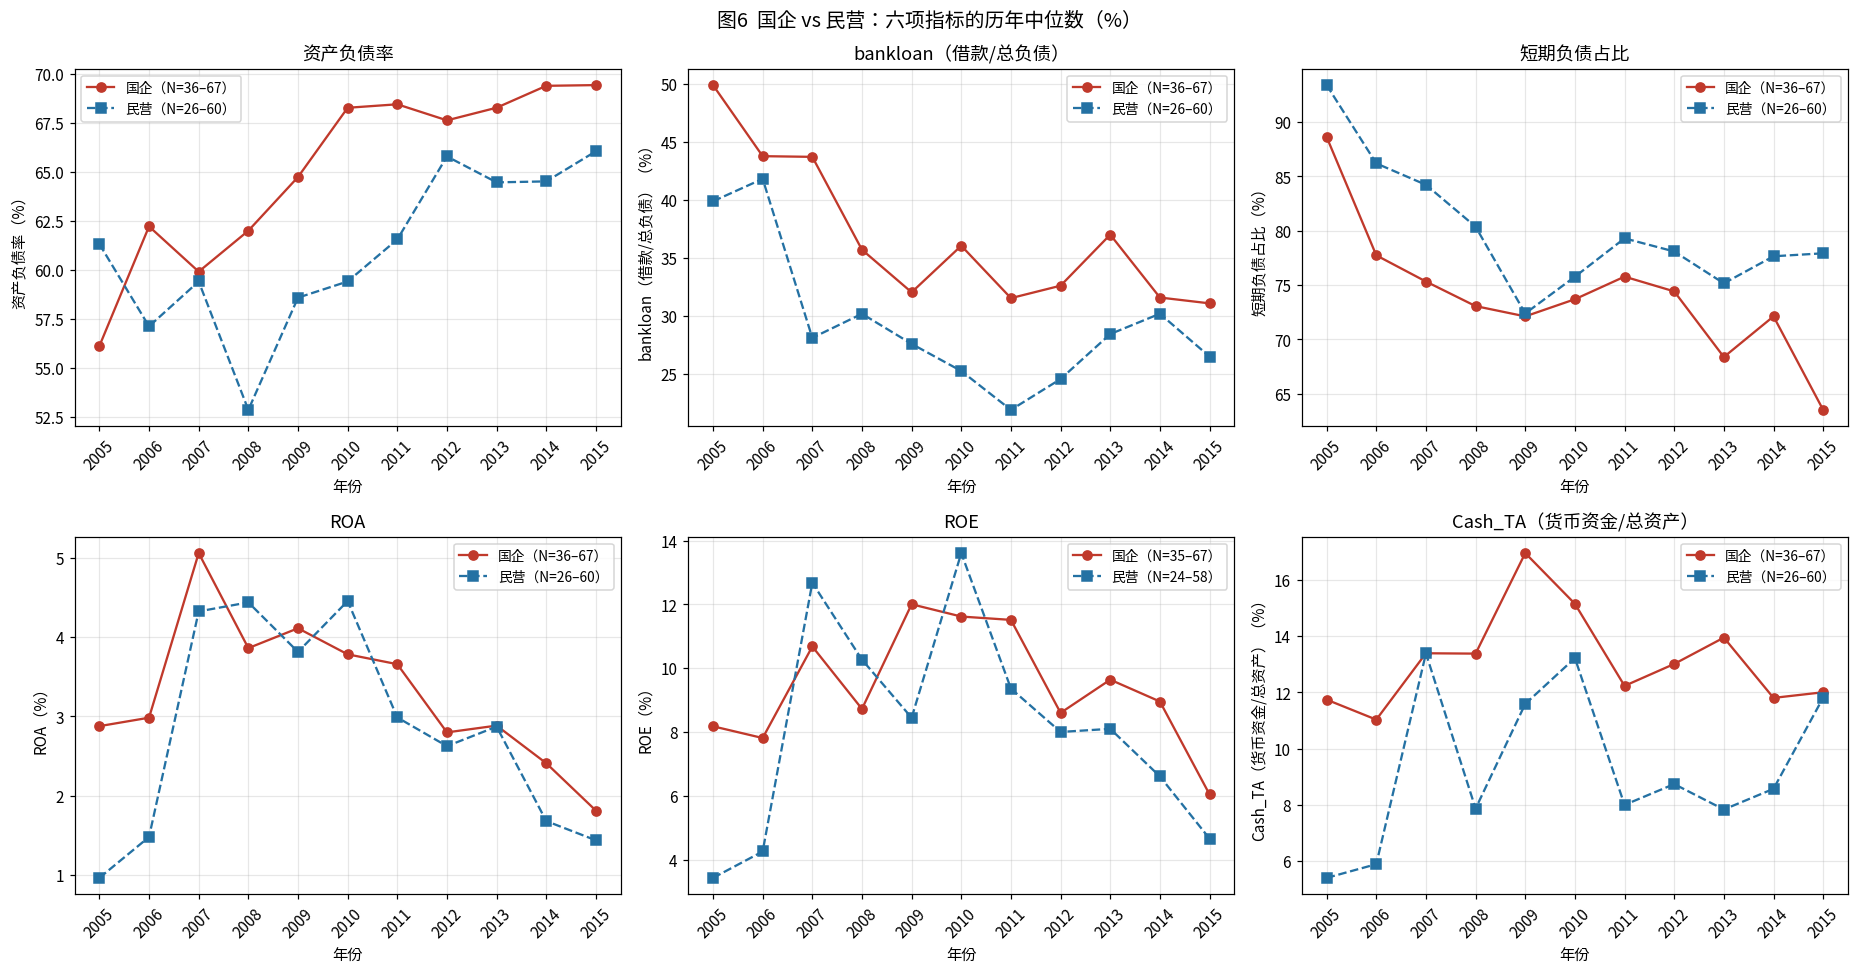

,国企中位数更高的年数(/11),国企均值更高的年数(/11),合并中位数：国企%,合并中位数：民营%,N 国企,N 民营
资产负债率,10,6,66.1005,61.5616,582,499
bankloan（借款/总负债）,11,9,34.8406,27.5282,581,498
短期负债占比,0,2,73.1327,79.2305,582,499
ROA,9,8,3.1469,2.4554,579,493
ROE,8,6,9.2437,7.2814,577,478
Cash_TA（货币资金/总资产）,11,10,13.0204,9.2459,582,499


In [14]:
print("国企 vs 民营：年度中位数（%）"); display(med_own.round(2))
own_plot("median", "图6  国企 vs 民营：六项指标的历年中位数（%）", "fig6_soe_private_median.png")
summ = pd.DataFrame({IND[v]: {
    "国企中位数更高的年数(/11)": int((med_own[(IND[v], "国企−民营")] > 0).sum()),
    "国企均值更高的年数(/11)": int((mean_own[(IND[v], "国企−民营")] > 0).sum()),
    "合并中位数：国企%": 100 * d.loc[d.own == "国企", v].median(), "合并中位数：民营%": 100 * d.loc[d.own == "民营", v].median(),
    "N 国企": int(d.loc[d.own == "国企", v].count()), "N 民营": int(d.loc[d.own == "民营", v].count())} for v in IND}).T
ic = ["国企中位数更高的年数(/11)", "国企均值更高的年数(/11)", "N 国企", "N 民营"]
summ[ic] = summ[ic].astype(int)
summ.to_csv(TAB / "soe_private_summary.csv", encoding="utf-8-sig")
display(summ)

**解读。** 以中位数衡量，11 年中国企有 10 年资产负债率更高、11 年 bankloan 更高、11 年短期负债占比更低、11 年 Cash_TA 更高。合并样本的中位数分别为：资产负债率 66.1% 对 61.6%，bankloan 34.8% 对 27.5%，短期负债占比 73.1% 对 79.2%，Cash_TA 13.0% 对 9.2%。盈利方面，国企的 ROA 中位数有 9 年更高，但差距很小（2008 年以后在 ±0.75 个百分点以内）；ROE 有 8 年更高（9.2% 对 7.3%），方向不如前四个指标稳定。

这些差异**与**“国企更容易获得金融机构的长期借款”这一观点一致。但两组公司在规模、成立时间、所在地区、土地储备、上市方式等方面都不同，本作业没有控制这些因素，所以只能说产权**与**这些财务特征相关，不能说国有产权**导致**了它们。

**核心发现：**
- 描述性差异很稳定：国企杠杆更高、借款占比更高、债务期限更长、现金更多，而且不受离群值处理方式的影响；
- 盈利能力的差异小，方向也不稳定；
- 所有差异都是无条件的描述，不能作因果解释。

## 9. 离群值还是样本构成？

本节回答官方提出的问题：观察到的变化，是来自离群值，还是来自样本构成的变化？做法是比较两类公司。

- 全样本与“11 年都在样本中”的 48 家公司（平衡子样本）的中位数对比：如果两者变化相同，说明是公司自身在变化；
- 当年新进入的公司与上年已在样本中的公司的中位数对比。

In [15]:
bal = d.groupby("code").year.nunique()
bal = bal[bal == Y1 - Y0 + 1].index
comp = pd.DataFrame({(IND[v], k): 100 * (d if k == "全样本" else d[d.code.isin(bal)]).groupby("year")[v].median()
                     for v in ["lev", "bankloan", "roe", "cash_ta"] for k in ["全样本", "平衡子样本"]})
print("平衡子样本公司数:", len(bal)); display(comp.round(2))
d["新进入"] = d.entry.isin(["新上市", "从其他行业转入"])
display((100 * d[d.year > Y0].groupby("新进入")[list(IND)].median()).rename(columns=IND)
        .rename(index={True: "当年新进入", False: "上年已在样本"}).round(2))

平衡子样本公司数: 48


资产负债率         bankloan（借款/总负债）             ROE         Cash_TA（货币资金/总资产）        
         全样本   平衡子样本              全样本   平衡子样本     全样本   平衡子样本               全样本   平衡子样本
year                                                                                   
2005 58.7300 57.0400          45.6600 45.2100  4.8500  5.6000            8.1000 11.6400
2006 59.5300 57.9900          40.9700 40.9700  5.9700  7.4200            8.7500  8.8400
2007 60.7200 53.9100          35.7500 36.6300 11.1300 11.7400           13.4800 13.7000
2008 57.0700 58.0300          34.8400 35.3000  9.2000  9.2500           10.5600 11.5500
2009 62.5900 61.7400          29.8100 32.9800 10.2700  9.7800           15.2400 14.4500
2010 64.8700 64.0000          29.8200 35.0900 11.9900 10.6700           14.3200 15.4100
2011 65.9400 64.0500          25.5600 26.5600 10.7300  9.7000           10.4500 10.8000
2012 65.9200 62.9200          27.8500 33.3900  8.4000  7.5500           11.1700 10.9400
2013 66.8900 65.3600          32.6400 38.6000  9.0000  6.7800           10.8800 10.5800
2014 67.5800 66.3700          31.9100 35.3600  8.1200  8.3800           11.0000  9.8800
2015 67.6600 64.9100          27.3600 31.9700  5.5700  6.0500           12.0900 10.6700

,资产负债率,bankloan（借款/总负债）,短期负债占比,ROA,ROE,Cash_TA（货币资金/总资产）
新进入,,,,,,
上年已在样本,64.8200,31.7600,72.7400,2.8100,8.6600,11.8700
当年新进入,63.1400,23.7900,78.5800,6.0500,15.9700,11.8400


**解读。** 资产负债率的中位数在全样本中从 58.7% 升到 67.7%，在平衡子样本中也从 57.0% 升到 64.9%，所以杠杆上升主要是**公司自身的变化**。bankloan 的中位数在全样本中下降了 18.3 个百分点，在平衡子样本中只下降了 13.2 个百分点；当年新进入公司的中位数（23.8%）也低于存续公司（31.8%）。这说明约 28% 的下降来自**样本构成**。新进入公司的 ROE 中位数为 16.0%，存续公司为 8.7%，因此进入较多的年份（2008—2010、2012）的盈利指标会被样本构成推高。

**核心发现：**
- 2005—2009 年资产负债率、ROA、ROE 均值的异常 → 来自**离群值**；
- bankloan 的下降和部分盈利波动 → 有相当一部分来自**样本构成**；
- 杠杆上升 → 主要是公司自身的变化。

**需要谨慎解读的年份：**
- **2005—2007：** 样本小，ST 壳公司集中；2007 年起执行新会计准则，2005—2006 年的净利润与权益口径可能不完全可比；
- **2009：** ST兴业使资产负债率均值高达 112%；
- **2009—2012：** 行业转入、转出密集，样本构成变化大；
- **2015：** 产权不明的观测为历年最多（5 个），另有 2 家当年上市的公司缺少 ROA/ROE。

## 10. 总体结论

按逐年的行业、产权和上市状态，2005—2015 年共有 **1,193 个公司-年、172 家**房地产上市公司，构成非平衡面板。公司数从 65 家增加到 136 家，增长主要来自其他行业公司的转入（97 家次），而不是 IPO（10 家次）；真正终止上市的只有 2 家，都是被吸收合并。国企始终是最大群体，但占比从 55.4% 降到 46.3%。六项指标中，中位数口径下：资产负债率从 58.7% 升到 67.7%，借款占比从 45.7% 降到 27.4%，短期负债占比从 87.8% 降到 69.1%，ROA 与 ROE 在 2007—2010 年达到高点后，2015 年降到 1.7% 和 5.6%，Cash_TA 从 8.1% 升到 12.1%。

**核心发现：**
1. **历史口径很重要：** 如果用 2015 年的名单回填历史，会错误地计入 97 家次、遗漏 34 家次的公司-年。
2. **均值与中位数：** 资产负债率、ROA、ROE 的均值在 2005—2009 年被少数 ST 壳公司扭曲（2009 年资产负债率均值为 112%，中位数为 63%），缩尾会让组间差异方向改变 1—2 年；三个有界指标则不受影响。主结果保留原始值，解读以中位数为主。
3. **国企与民营的描述性差异：** 国企杠杆更高（66.1% 对 61.6%）、借款占比更高（34.8% 对 27.5%）、短期负债占比更低（73.1% 对 79.2%）、现金更多（13.0% 对 9.2%），11 年中方向几乎不变；盈利差异小且不稳定。这是相关关系，不是因果关系。
4. **离群值还是样本构成：** 均值的异常主要来自离群值；借款占比的下降约 28% 来自样本构成；杠杆上升主要是公司自身的变化。

**局限：**
- bankloan 用“短期借款 + 长期借款”作代理，其中包含其他金融机构的借款，但不包含一年内到期的长期借款，偏差方向无法确定；
- 2007 年会计准则变更前后，净利润与权益口径可能不完全可比；
- “其他”与“产权不明”样本太小，没有单独比较；
- 行业分类依赖 CSMAR 用 2012 版标准对早期年份的归类；
- 没有控制规模、地区等因素，所有组间差异都是无条件的描述。

In [16]:
import sys, platform
print("Python", sys.version.split()[0], "|", platform.platform())
for p in sorted((BASE / "outputs").rglob("*.*")):
    print("  ", p.relative_to(BASE))

Python 3.11.15 | Linux-6.18.44-fc-v37-x86_64-with-glibc2.39
   outputs/figures/fig1_counts_ownership.png
   outputs/figures/fig2_boxplots_by_year.png
   outputs/figures/fig3_sensitivity.png
   outputs/figures/fig4_all_mean_median.png
   outputs/figures/fig5_soe_private_mean.png
   outputs/figures/fig6_soe_private_median.png
   outputs/qa/extreme_observations.csv
   outputs/qa/raw_zip_inventory.csv
   outputs/tables/all_firms_mean_median.csv
   outputs/tables/entry_exit_by_year.csv
   outputs/tables/firm_counts_by_ownership.csv
   outputs/tables/pooled_distribution.csv
   outputs/tables/sample_processing_table.csv
   outputs/tables/sensitivity_winsor.csv
   outputs/tables/soe_private_mean.csv
   outputs/tables/soe_private_median.csv
   outputs/tables/soe_private_summary.csv
   outputs/tables/valid_N_by_indicator_year_ownership.csv
